# 💳 Credit Card Fraud Detection — Full ML Lifecycle with Cost-Sensitive Learning

> **Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
> **Author:** Shalindra Perera  
> **Purpose:** complete pipeline from EDA → Classical ML → Ensemble ML → Cost-Sensitive Analysis

---

## ML Lifecycle Stages
1. Data Loading & Initial Exploration
2. Exploratory Data Analysis (EDA) & Visualisations
3. Preprocessing & Feature Engineering
4. Feature Selection (Pearson + Mutual Information)
5. Outlier Removal (IQR on fraud class)
6. Dimensionality Reduction (t-SNE, PCA, TruncatedSVD)
7. **Classical ML Models** — Stratified K-Fold CV with undersampling inside each fold
8. **Ensemble Models** — Random Forest (Balanced), XGBoost (Weighted), LightGBM, BalancedBagging
9. **Cost-Sensitive Learning** — class_weight tuning + explicit cost matrix threshold optimisation
10. Final Model Comparison & Business-Metric Summary

---

### ⚠️ Key Design Decisions
| Decision | Rationale |
|---|---|
| **RobustScaler** on Amount & Time | Both features have heavy-tailed distributions / outliers; RobustScaler uses median & IQR, making it robust to extremes |
| **Stratified splits** everywhere | Preserves the 0.17% fraud rate in every fold — essential for honest evaluation |
| **Resampling inside the fold** | Prevents data leakage: synthetic minority samples are never seen by the validation fold |
| **PR-AUC as primary metric** | With ~0.17% positive rate, ROC-AUC is overly optimistic; PR-AUC (Average Precision) better reflects minority-class detection quality |
| **Cost matrix via class_weight** | sklearn's `class_weight='balanced'` and `class_weight={0:1, 1:IR}` implement cost-sensitive training without resampling |
| **IQR outlier removal on fraud class only** | Removes extreme noise that distorts decision boundaries for the most important class |


---
## 0. Library Imports

In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings, time, os
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE = ['#2196F3', '#F44336']

# ── Scikit-learn — Preprocessing / Splitting ──────────────────────────────────
from sklearn.model_selection    import (train_test_split, StratifiedKFold,
                                        ShuffleSplit, cross_val_score,
                                        cross_val_predict, learning_curve)
from sklearn.preprocessing      import StandardScaler, RobustScaler
from sklearn.decomposition      import PCA, TruncatedSVD
from sklearn.manifold           import TSNE
from sklearn.pipeline           import Pipeline as SklearnPipeline
from sklearn.feature_selection  import mutual_info_classif

# ── Scikit-learn — Classifiers ────────────────────────────────────────────────
from sklearn.linear_model       import LogisticRegression
from sklearn.svm                import SVC
from sklearn.naive_bayes        import GaussianNB
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import (RandomForestClassifier,
                                        BaggingClassifier,
                                        GradientBoostingClassifier)

# ── Gradient Boosting Libraries ───────────────────────────────────────────────
from xgboost                    import XGBClassifier
from lightgbm                   import LGBMClassifier

# ── Imbalanced-learn ─────────────────────────────────────────────────────────
from imblearn.over_sampling     import SMOTE
from imblearn.under_sampling    import RandomUnderSampler, NearMiss
from imblearn.ensemble          import BalancedBaggingClassifier, BalancedRandomForestClassifier
from imblearn.pipeline          import Pipeline as ImbPipeline
from imblearn.pipeline          import make_pipeline as imbalanced_make_pipeline

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    balanced_accuracy_score, matthews_corrcoef
)
from scipy.stats import norm

print('✅  All libraries imported successfully')

✅  All libraries imported successfully


---
## 1. Data Loading & Initial Exploration

The dataset contains transactions made by European cardholders in September 2013.  
- **284,807 transactions** over two days  
- **492 frauds** → 0.172% of all transactions  
- Features V1–V28: principal components from PCA (original features are confidential)  
- `Time`: seconds elapsed between each transaction and the first transaction  
- `Amount`: transaction amount  
- `Class`: response variable (1 = Fraud, 0 = Legitimate)

In [ ]:
CSV_PATH = 'resources/creditcard.csv'   # ← update path if needed
df = pd.read_csv(CSV_PATH)

print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
df.head()

Shape   : (284807, 31)
Columns : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [5]:
# Check for nulls — none expected as per dataset documentation
print('Null counts:\n', df.isnull().sum())
print('\nTotal nulls:', df.isnull().sum().sum())

Null counts:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total nulls: 0


---
## 2. Class Imbalance Overview

Understanding the imbalance ratio (IR) is critical. With IR ≈ 578:1, a naive classifier that always predicts 'legitimate' achieves 99.83% accuracy — a completely misleading metric. This motivates the use of PR-AUC, recall, and cost-sensitive metrics throughout this study.

Legitimate transactions : 284,315  (99.83%)
Fraud transactions      : 492  (0.1727%)
Imbalance Ratio (IR)    : 577.9:1

Cost-Sensitive Note: Using IR=577.9 as the misclassification cost weight for fraud.
This means a false negative (missed fraud) costs 578x more than a false positive.


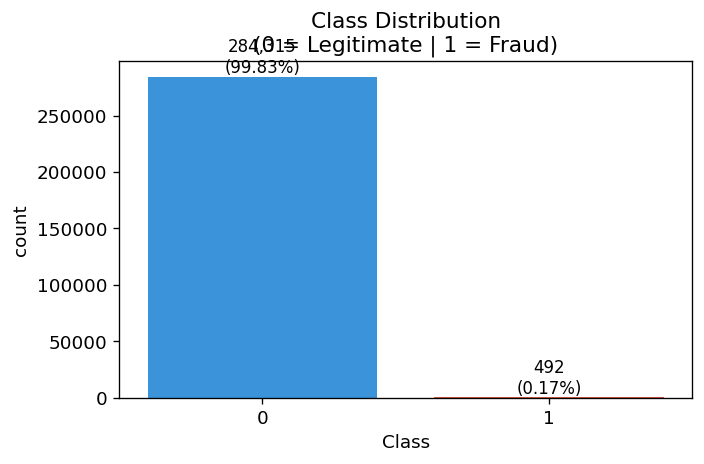

In [6]:
class_counts = df['Class'].value_counts()
IR = class_counts[0] / class_counts[1]

print(f'Legitimate transactions : {class_counts[0]:,}  ({100*class_counts[0]/len(df):.2f}%)')
print(f'Fraud transactions      : {class_counts[1]:,}  ({100*class_counts[1]/len(df):.4f}%)')
print(f'Imbalance Ratio (IR)    : {IR:.1f}:1')
print(f'\nCost-Sensitive Note: Using IR={IR:.1f} as the misclassification cost weight for fraud.')
print(f'This means a false negative (missed fraud) costs {IR:.0f}x more than a false positive.')

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=PALETTE, ax=ax)
ax.set_title('Class Distribution\n(0 = Legitimate | 1 = Fraud)', fontsize=13)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}\n({100*p.get_height()/len(df):.2f}%)',
                (p.get_x() + p.get_width() / 2.,  p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

---
## 3. EDA — Distributions of Amount & Time

**Amount** is log-transformed for visualisation because its right-skewed distribution (many small, few large transactions) compresses the histogram when plotted on a linear scale.  
**Time** shows two peaks — a well-known pattern consistent with day/night transaction cycles in the 48-hour window.

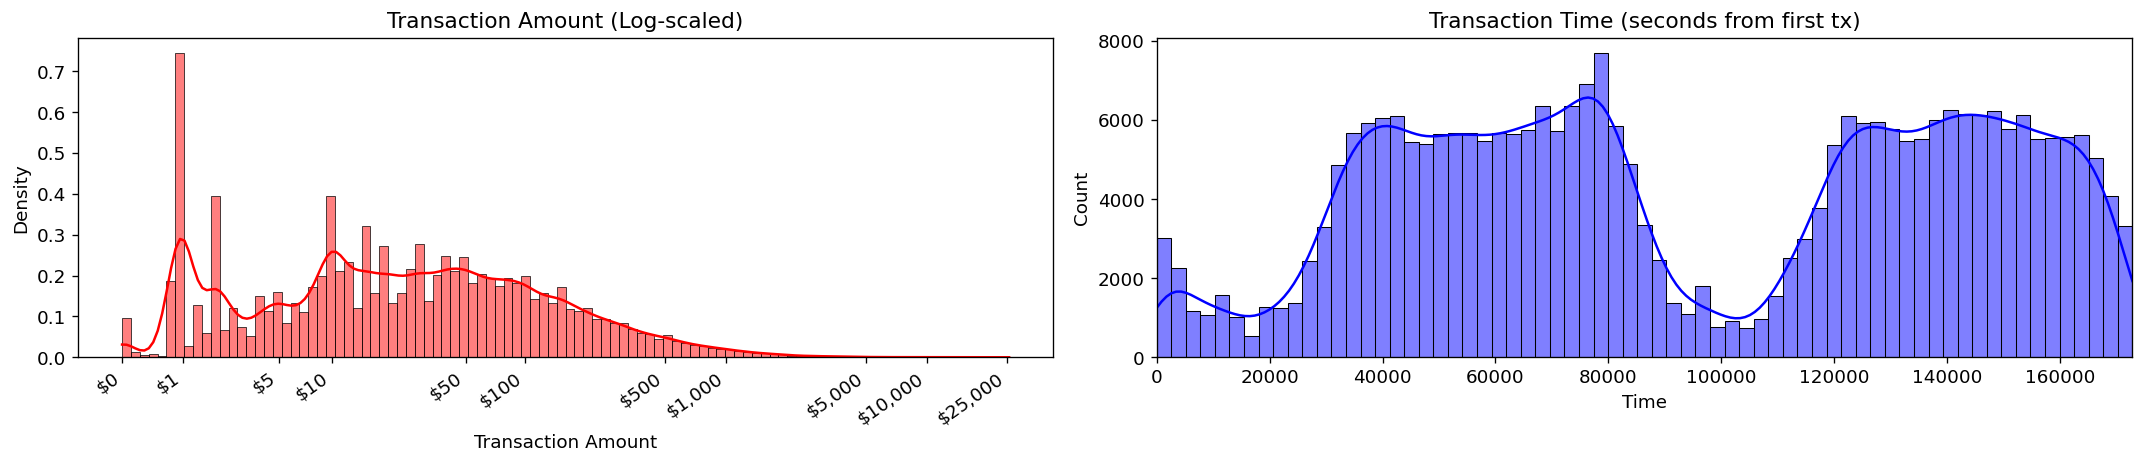

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

amount_val = df['Amount'].values
time_val   = df['Time'].values

# Log-transform for heavily skewed amount distribution
amount_log = np.log1p(amount_val)

sns.histplot(amount_log, ax=ax[0], color='r', kde=True, stat='density', bins=100)
ax[0].set_title('Transaction Amount (Log-scaled)', fontsize=13)
ax[0].set_ylabel('Density')
tick_candidates = np.array([0, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 25000], dtype=float)
ticks_raw = tick_candidates[tick_candidates <= amount_val.max()]
ticks_log = np.log1p(ticks_raw)
ax[0].set_xticks(ticks_log)
ax[0].set_xticklabels([f'${int(t):,}' for t in ticks_raw], rotation=35, ha='right')
ax[0].set_xlabel('Transaction Amount')

sns.histplot(time_val, ax=ax[1], color='b', kde=True)
ax[1].set_title('Transaction Time (seconds from first tx)', fontsize=13)
ax[1].set_xlabel('Time')
ax[1].set_xlim([time_val.min(), time_val.max()])

plt.tight_layout()
plt.show()

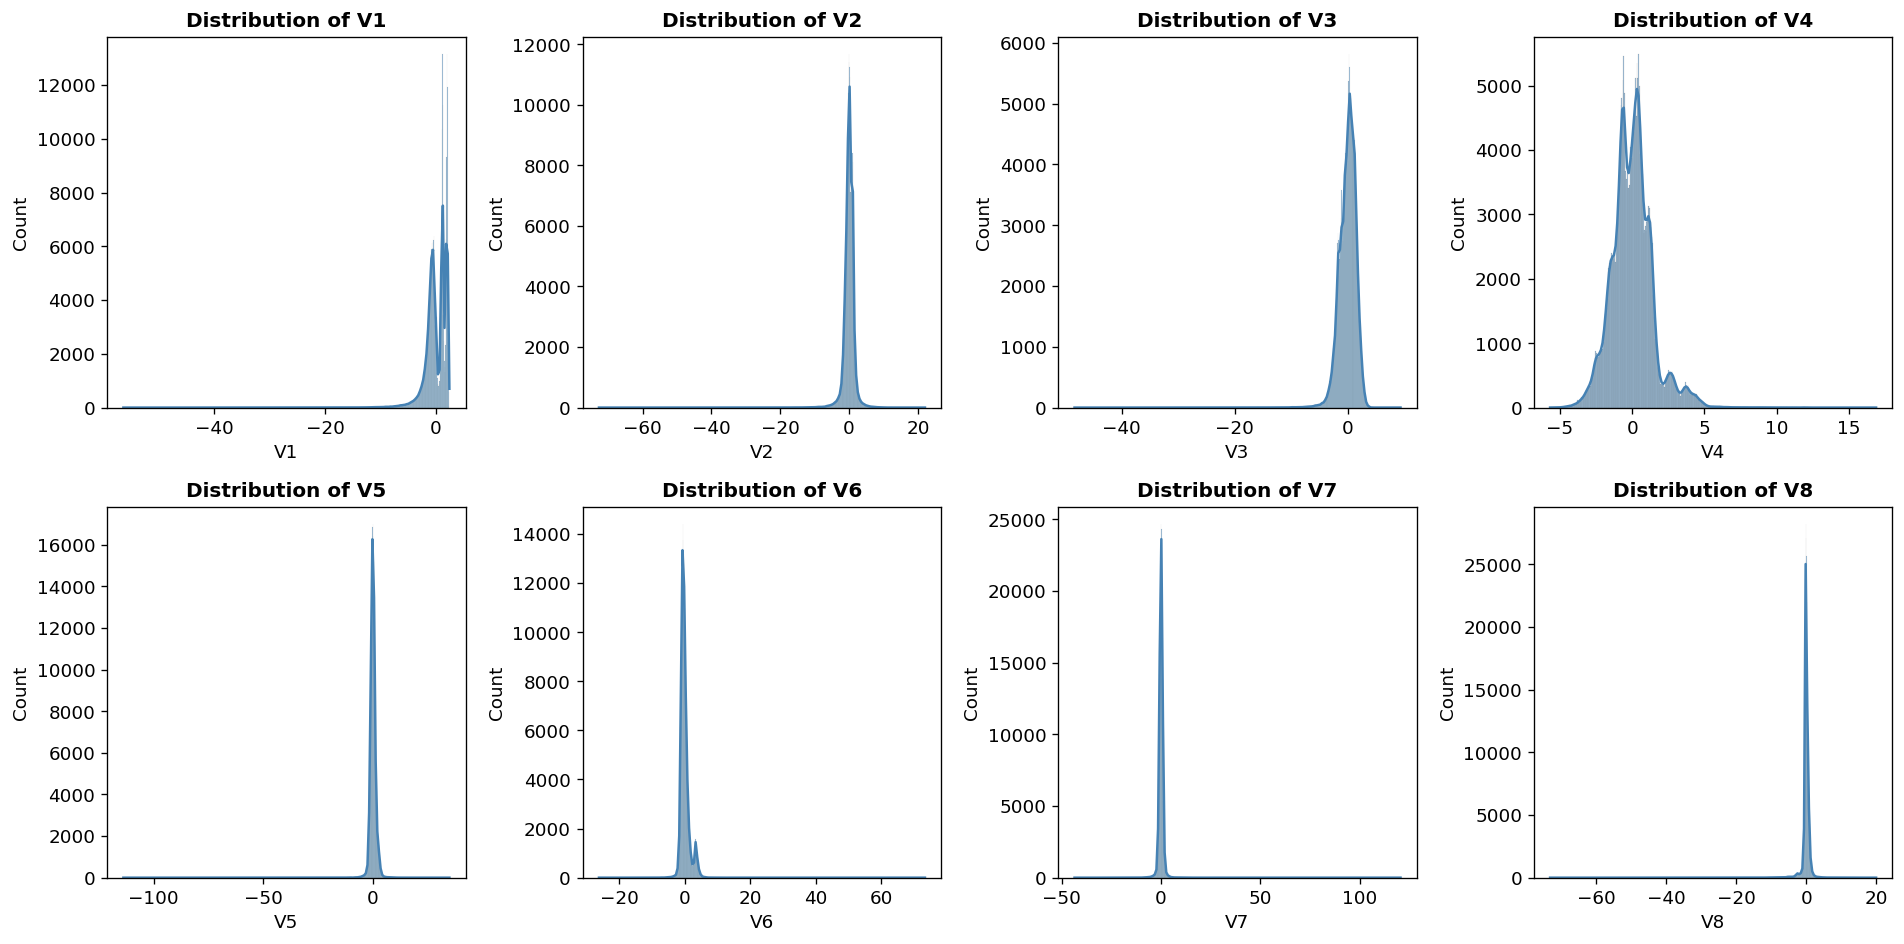

In [8]:
# Distributions of V1–V8 to sample the PCA feature space
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate([f'V{i}' for i in range(1, 9)]):
    sns.histplot(df[col], ax=axes[idx], kde=True, color='steelblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 4. Preprocessing — Scaling Amount & Time

V1–V28 are already PCA-transformed and thus already scaled. We apply **RobustScaler** specifically to `Amount` and `Time` because:
- `Amount` has extreme right-skew and many outliers (a StandardScaler would be distorted by those extremes)
- `Time` is uniformly distributed but on a very different scale (~172,792 seconds)
- RobustScaler uses the **median** and **IQR** — unaffected by extreme values — making it the correct choice here

In [9]:
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time']   = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Reorder: scaled features first
scaled_amount = df.pop('scaled_amount')
scaled_time   = df.pop('scaled_time')
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time',   scaled_time)

print('Scaling complete. New column order:')
print(list(df.columns[:5]), '...')
df.head(3)

Scaling complete. New column order:
['scaled_amount', 'scaled_time', 'V1', 'V2', 'V3'] ...


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0


---
## 5. Train / Test Split on the ORIGINAL Imbalanced Dataset

**Critical design principle:** We split the *original imbalanced* dataset first, before any resampling.  
The test set must reflect the **real-world class distribution** (99.83% legit / 0.17% fraud).  
Resampling (SMOTE / undersampling) is applied only to the **training set** inside cross-validation folds.  

This avoids the common pitfall of applying SMOTE before splitting, which causes **data leakage** — synthetic minority samples generated from the same instances that appear in the test set inflate performance estimates unrealistically.

In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split preserves the 0.17% fraud rate in both train and test
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Original imbalanced split:')
print(f'  Train: {X_train_orig.shape[0]:,} samples | Fraud: {y_train_orig.sum():,} ({100*y_train_orig.mean():.3f}%)')
print(f'  Test : {X_test_orig.shape[0]:,} samples | Fraud: {y_test_orig.sum():,} ({100*y_test_orig.mean():.3f}%)')

# Cross-validation strategy — stratified to maintain class proportions in every fold
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Original imbalanced split:
  Train: 227,845 samples | Fraud: 394 (0.173%)
  Test : 56,962 samples | Fraud: 98 (0.172%)


---
## 6. Random Undersampling Subsample — EDA on Balanced Data

We create a **balanced subsample (50/50)** for EDA and correlation analysis ONLY.  
Why? Correlations computed on the imbalanced dataset are dominated by the majority class signal and do not reflect the true feature-to-fraud relationship.  
This balanced subsample is **not** used to train final models — that would throw away 99.65% of legitimate transaction data.

Balanced subsample distribution:
Class
0    492
1    492
Name: count, dtype: int64


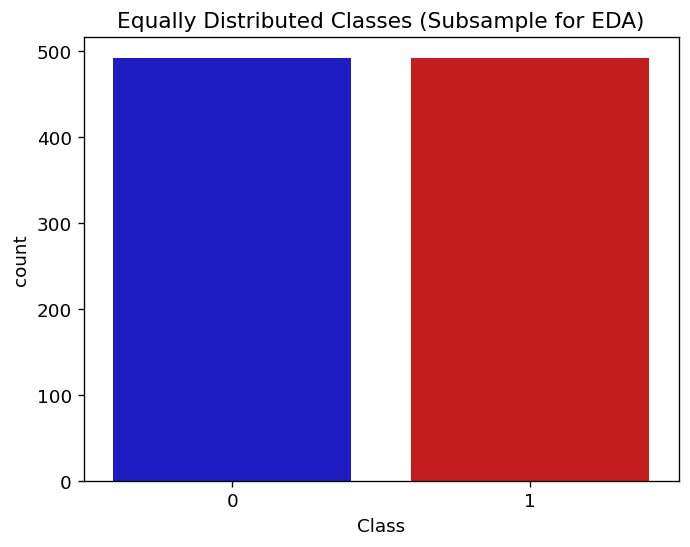

In [11]:
df_shuffled = df.sample(frac=1, random_state=42)

fraud_df     = df_shuffled.loc[df_shuffled['Class'] == 1]
non_fraud_df = df_shuffled.loc[df_shuffled['Class'] == 0][:492]

underSample_new_df = pd.concat([fraud_df, non_fraud_df]).sample(frac=1, random_state=42)

print('Balanced subsample distribution:')
print(underSample_new_df['Class'].value_counts())

sns.countplot(x='Class', data=underSample_new_df, palette=['#0101DF', '#DF0101'])
plt.title('Equally Distributed Classes (Subsample for EDA)', fontsize=13)
plt.show()

---
## 7. Feature Selection — Pearson Correlation + Mutual Information

We combine two complementary measures:  
- **Pearson Correlation**: captures *linear* relationships between each feature and the target  
- **Mutual Information**: captures *non-linear* dependencies — important because fraud patterns are often non-linear  

Both are normalised to [0,1] and averaged to produce a composite ranking. This avoids bias toward either purely linear or purely rank-based methods.

               Pearson Correlation  Mutual Information  Average Score
V14                         0.7487              0.4721         1.0000
V4                          0.7178              0.3943         0.8970
V12                         0.6797              0.4129         0.8912
V10                         0.6264              0.4371         0.8813
V11                         0.6835              0.3770         0.8557
V17                         0.5611              0.4539         0.8554
V16                         0.5987              0.3642         0.7856
V3                          0.5635              0.3759         0.7745
V7                          0.4750              0.3034         0.6386
V2                          0.4903              0.2625         0.6055
V9                          0.5588              0.2113         0.5969
V18                         0.4732              0.2149         0.5436
V1                          0.4307              0.1850         0.4835
V6                  

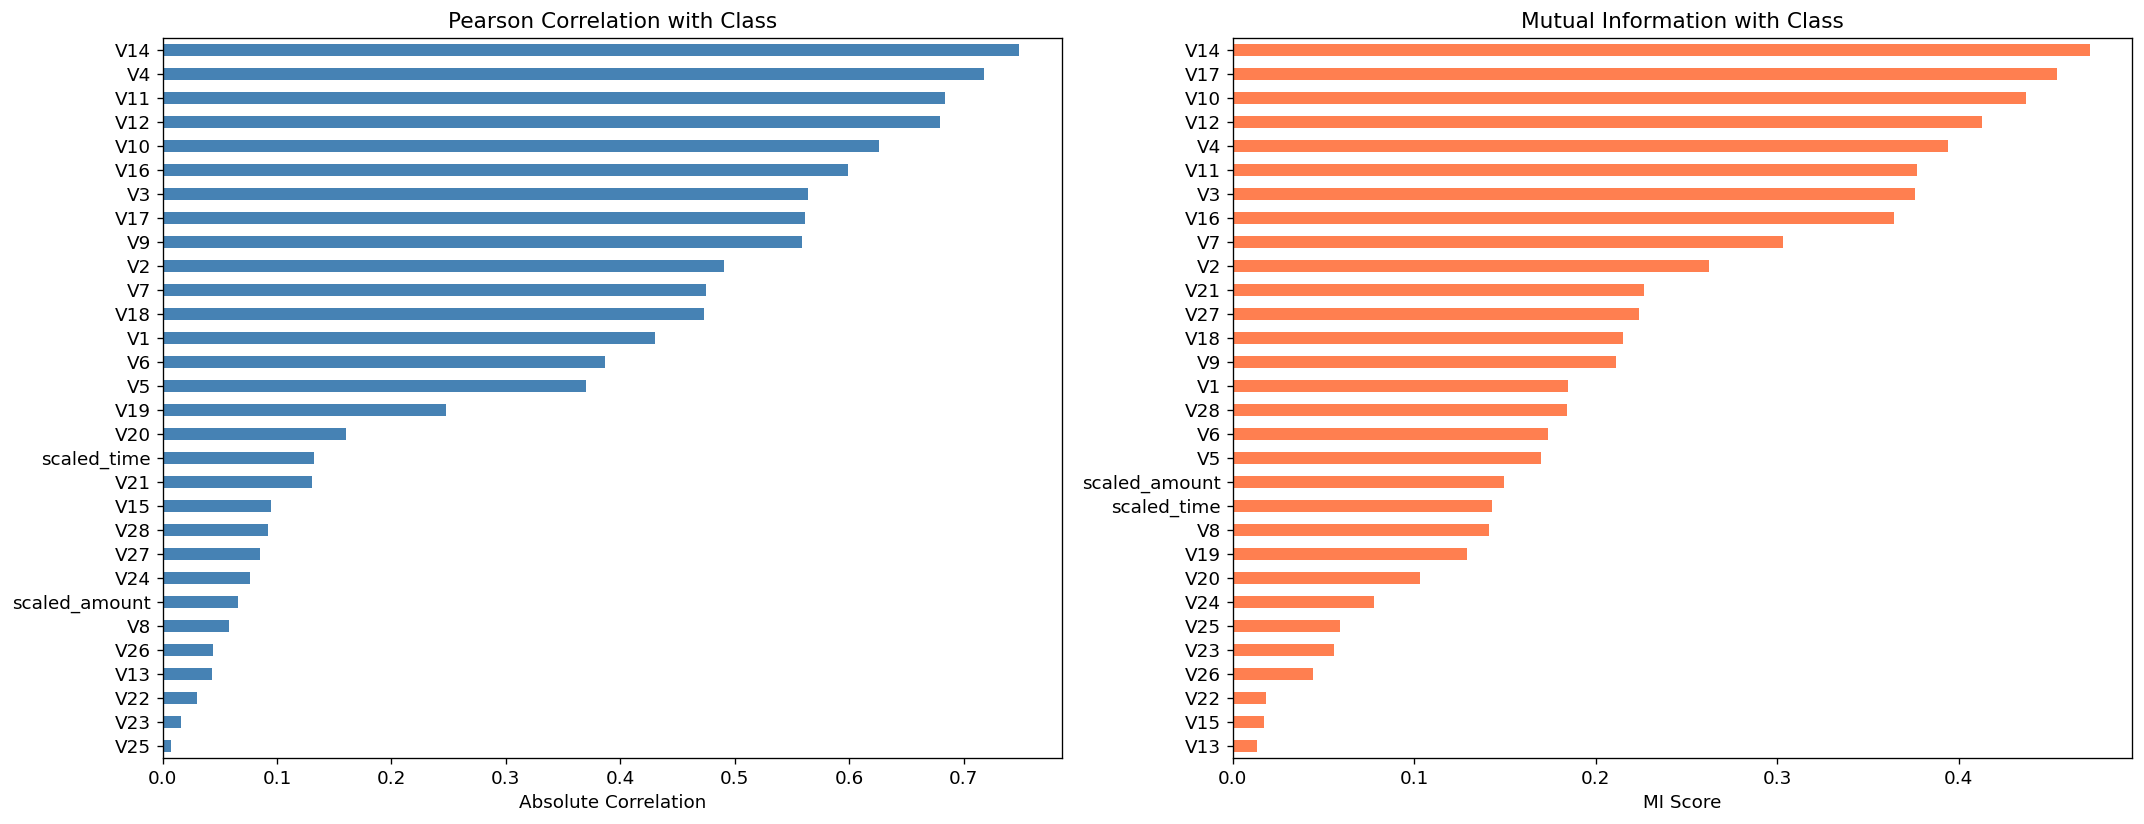


Features with Average Score > 0.1: 24
['V14', 'V4', 'V12', 'V10', 'V11', 'V17', 'V16', 'V3', 'V7', 'V2', 'V9', 'V18', 'V1', 'V6', 'V5', 'V21', 'V19', 'V27', 'V28', 'scaled_time', 'V20', 'scaled_amount', 'V8', 'V24']

Features with Mutual Information > 0.1: 23
['V14', 'V4', 'V12', 'V10', 'V11', 'V17', 'V16', 'V3', 'V7', 'V2', 'V9', 'V18', 'V1', 'V6', 'V5', 'V21', 'V19', 'V27', 'V28', 'scaled_time', 'V20', 'scaled_amount', 'V8']


In [12]:
def feature_eng(balanced_df, top_n=10, threshold=0.1):
    X_eda = balanced_df.drop('Class', axis=1)
    y_eda = balanced_df['Class']

    pearson_corr = X_eda.corrwith(y_eda).abs().sort_values(ascending=False)

    mi_scores = mutual_info_classif(X_eda, y_eda, random_state=42)
    mi_series = pd.Series(mi_scores, index=X_eda.columns).sort_values(ascending=False)

    feature_scores = pd.DataFrame({
        'Pearson Correlation': pearson_corr,
        'Mutual Information':  mi_series
    })
    feature_scores['Pearson Norm']  = feature_scores['Pearson Correlation'] / feature_scores['Pearson Correlation'].max()
    feature_scores['MI Norm']       = feature_scores['Mutual Information']  / feature_scores['Mutual Information'].max()
    feature_scores['Average Score'] = (feature_scores['Pearson Norm'] + feature_scores['MI Norm']) / 2
    feature_scores = feature_scores.sort_values('Average Score', ascending=False)

    print(feature_scores[['Pearson Correlation', 'Mutual Information', 'Average Score']].round(4))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    feature_scores['Pearson Correlation'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('Pearson Correlation with Class', fontsize=13)
    axes[0].set_xlabel('Absolute Correlation')

    feature_scores['Mutual Information'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title('Mutual Information with Class', fontsize=13)
    axes[1].set_xlabel('MI Score')

    plt.tight_layout()
    plt.show()

    selected_avg = feature_scores[feature_scores['Average Score'] > threshold].index.tolist()
    selected_mi  = feature_scores[feature_scores['Mutual Information'] > threshold].index.tolist()

    print(f'\nFeatures with Average Score > {threshold}: {len(selected_avg)}')
    print(selected_avg)
    print(f'\nFeatures with Mutual Information > {threshold}: {len(selected_mi)}')
    print(selected_mi)

    return feature_scores

feature_scores = feature_eng(underSample_new_df)

---
## 8. Correlation Matrices — Balanced vs Imbalanced

The imbalanced correlation matrix is shown for reference only — it is misleading because the 99.83% majority class overwhelms the signal. The **balanced subsample correlation matrix** is the one used to identify features for outlier treatment and model interpretation.

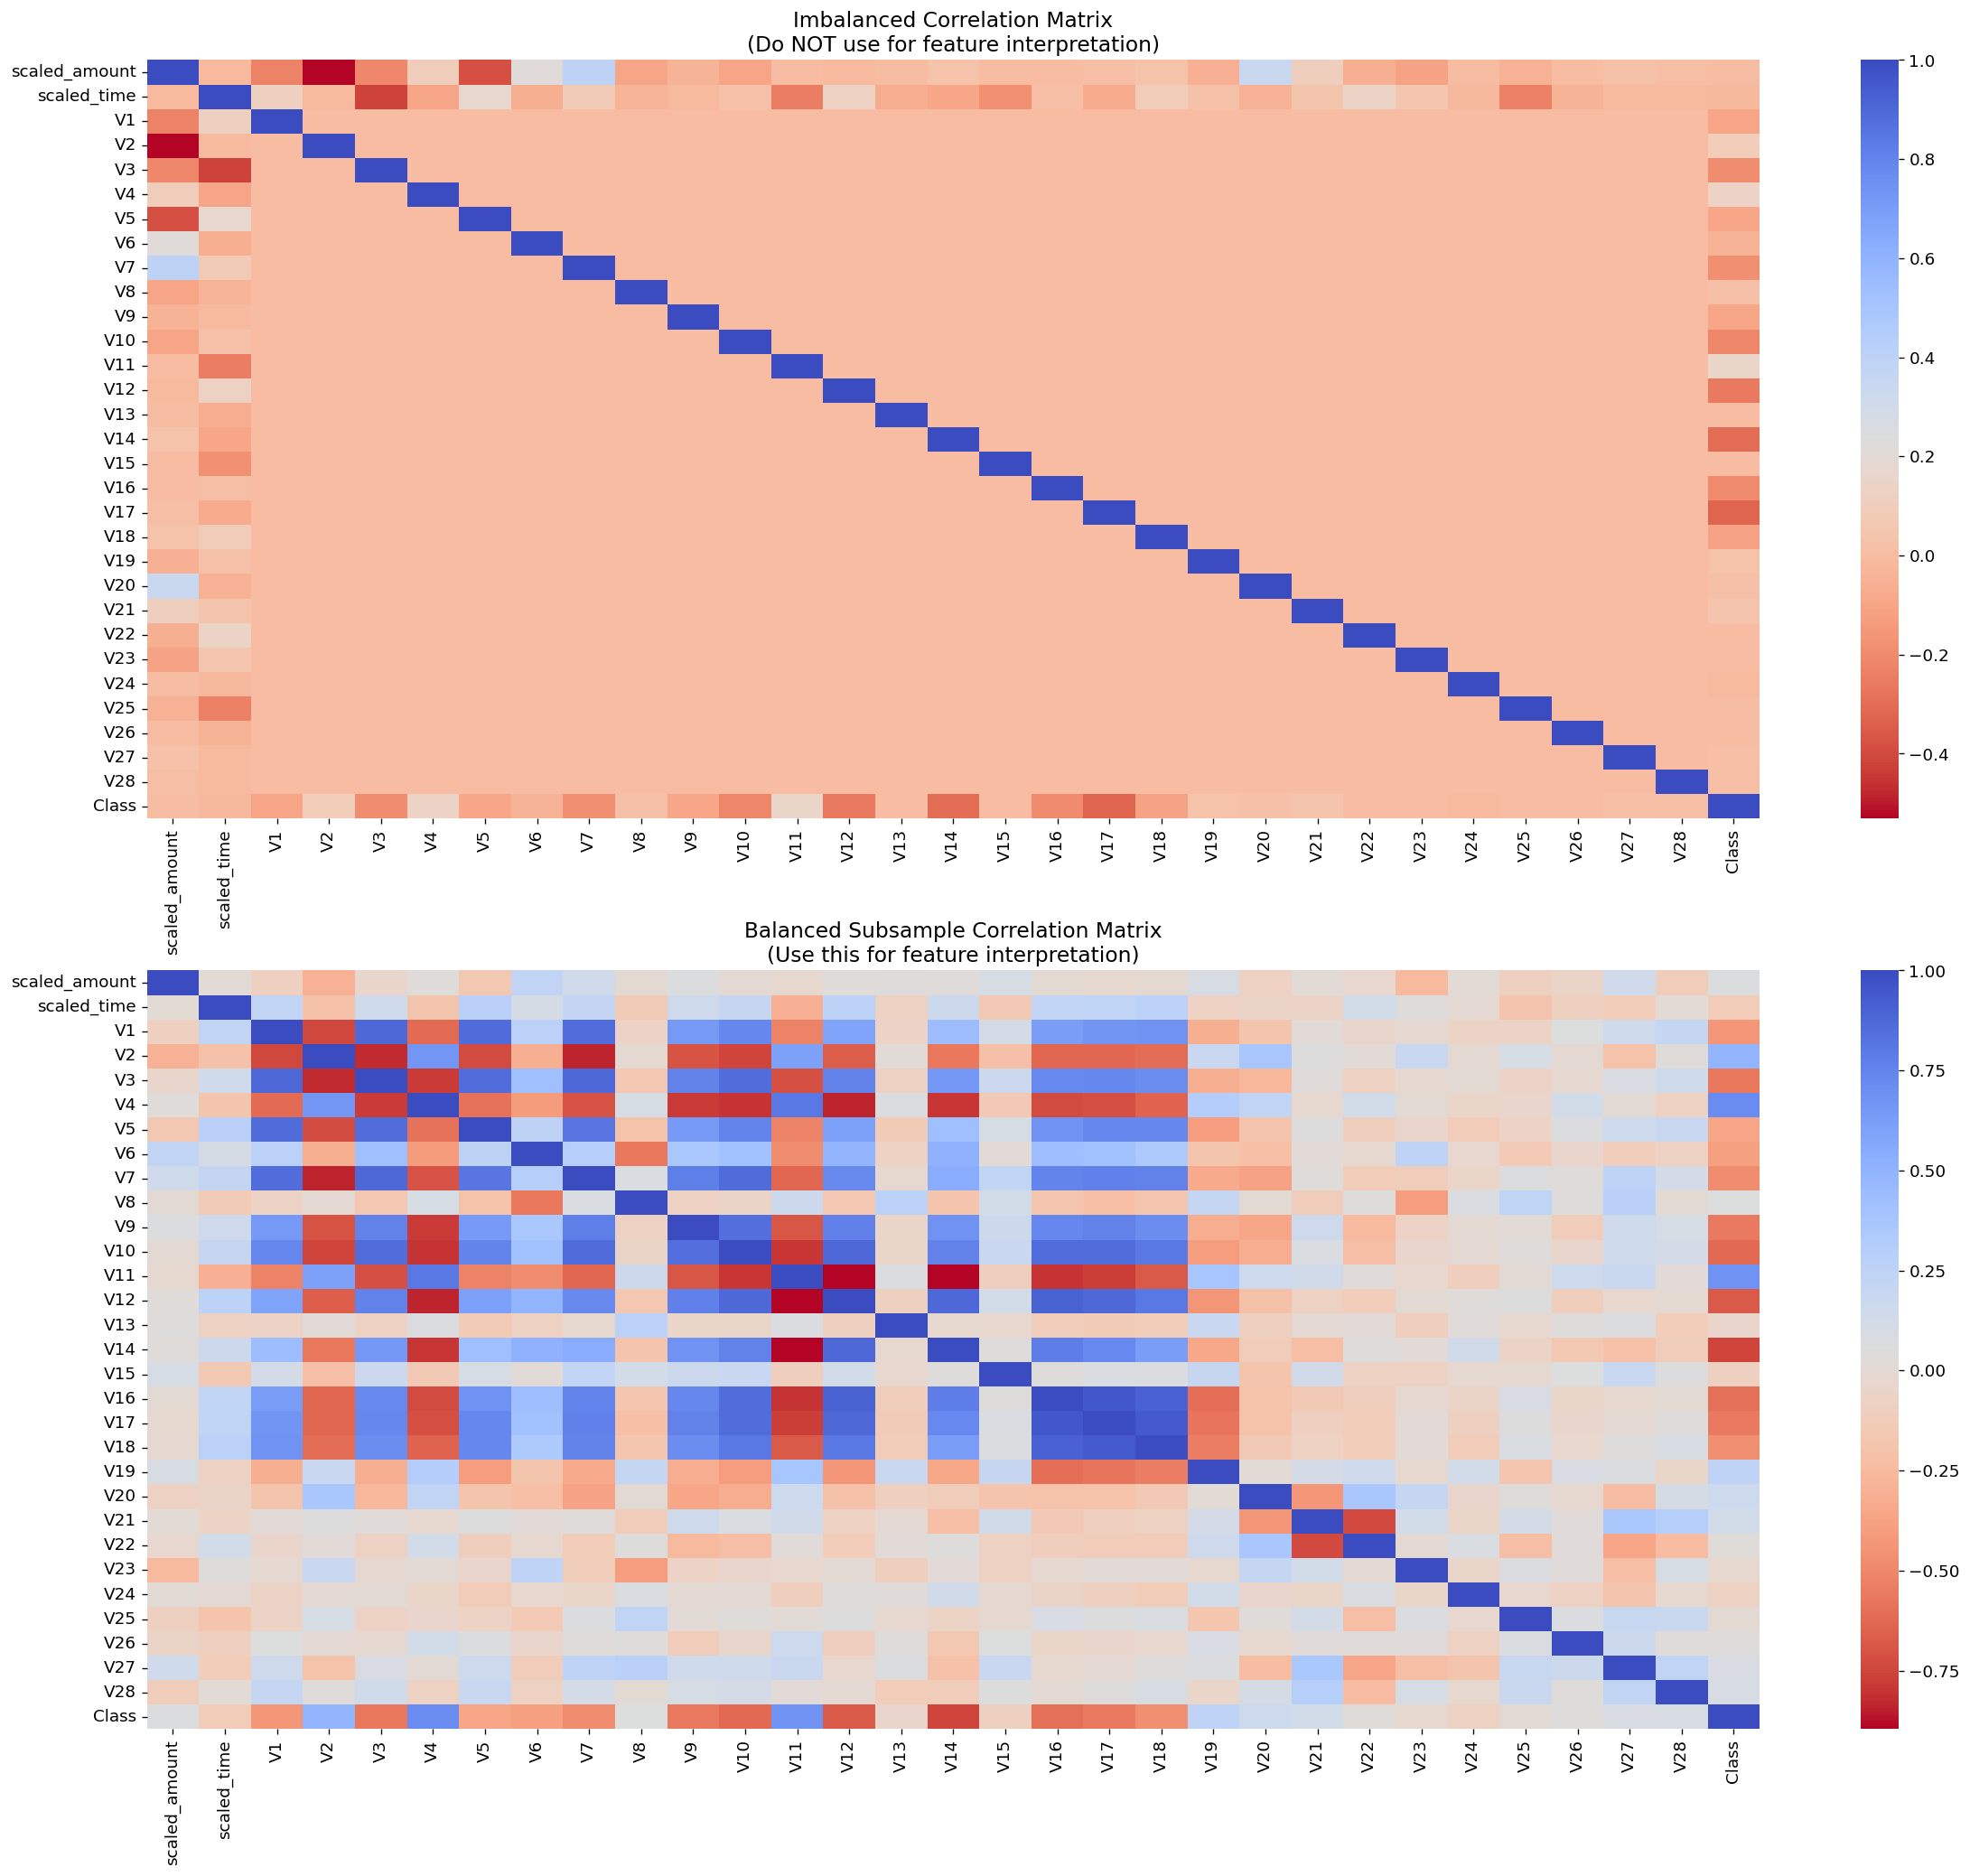

In [13]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 20))

corr_imb = df.corr()
sns.heatmap(corr_imb, cmap='coolwarm_r', annot_kws={'size': 8}, ax=ax1, fmt='.1f')
ax1.set_title("Imbalanced Correlation Matrix\n(Do NOT use for feature interpretation)", fontsize=14)

corr_bal = underSample_new_df.corr()
sns.heatmap(corr_bal, cmap='coolwarm_r', annot_kws={'size': 8}, ax=ax2, fmt='.1f')
ax2.set_title('Balanced Subsample Correlation Matrix\n(Use this for feature interpretation)', fontsize=14)

plt.show()

---
## 9. Box Plots — Negative & Positive Correlated Features

**Negative correlated features** (V17, V14, V12, V10, V16, V3, V9, V7): Lower values → higher probability of fraud.  
**Positive correlated features** (V11, V4, V2, V19): Higher values → higher probability of fraud.  
These features show clear median separation between classes — strong discriminatory signal.

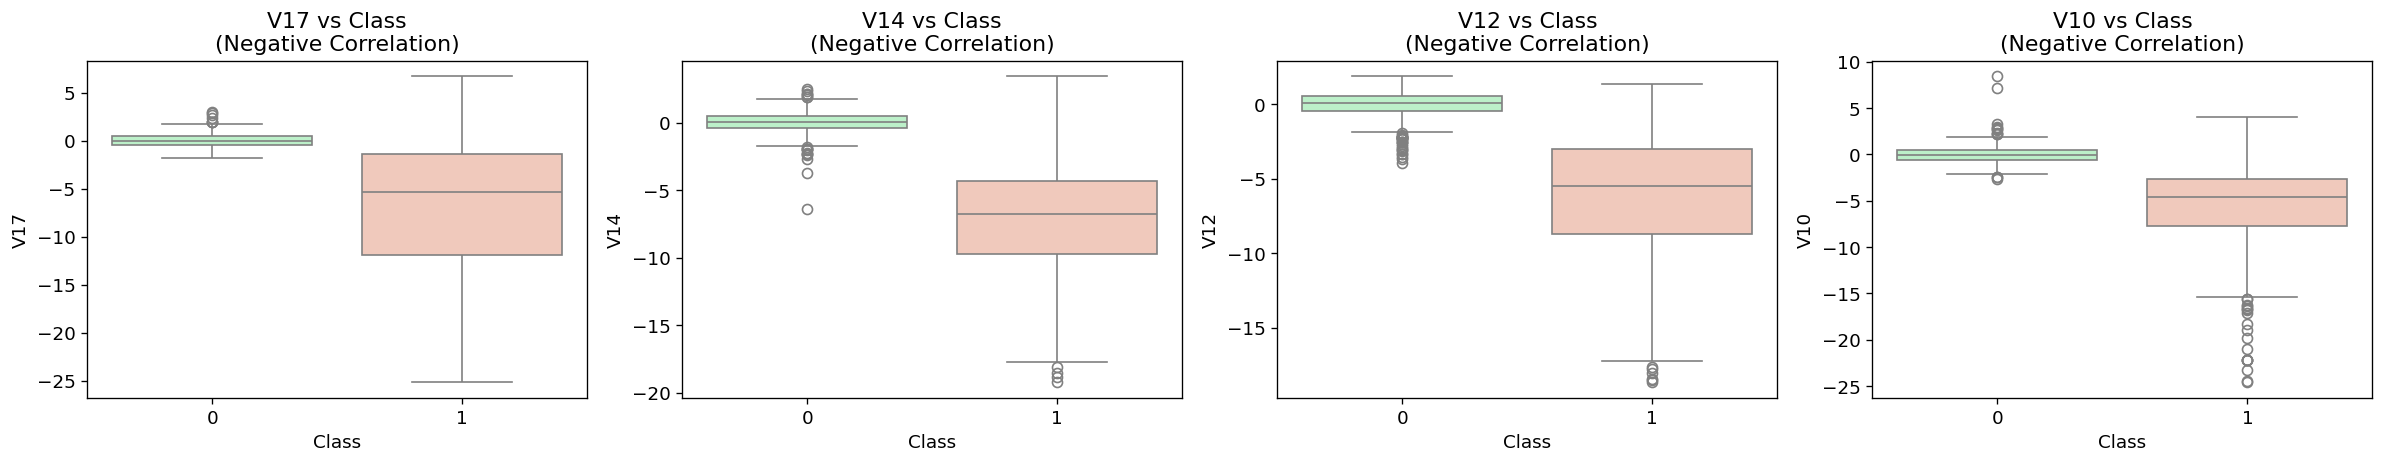

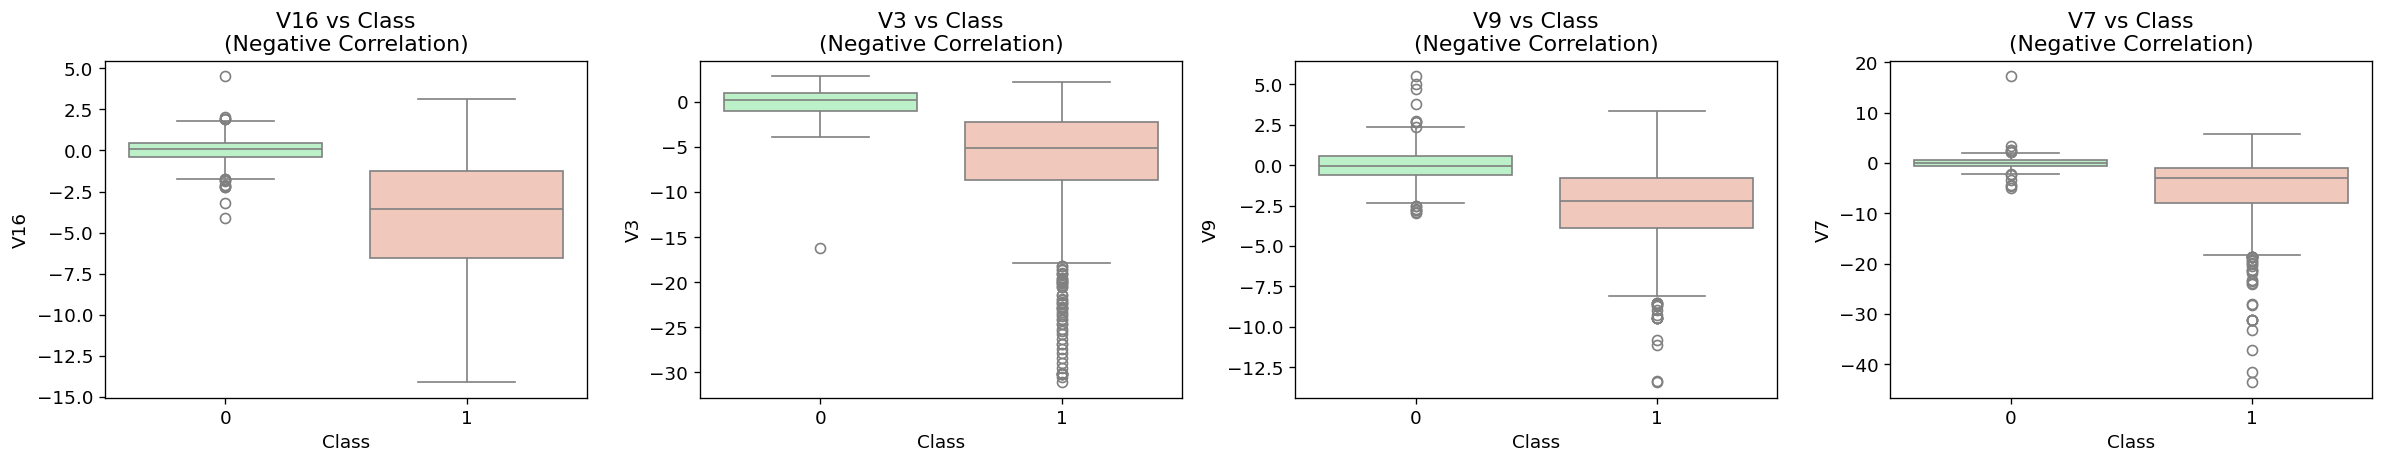

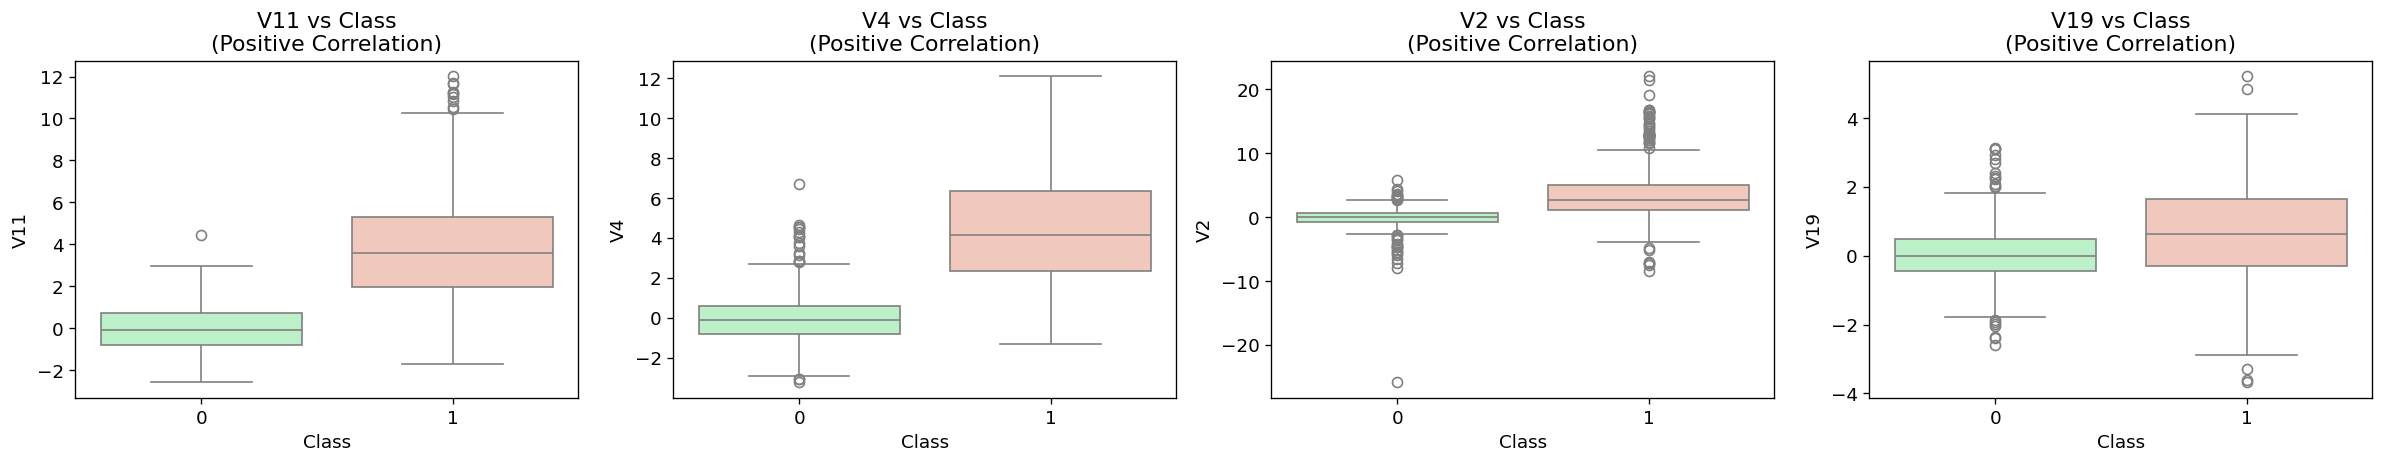

In [14]:
colors = ['#B3F9C5', '#f9c5b3']

f, axes = plt.subplots(ncols=4, figsize=(20, 4))
for ax, feat in zip(axes, ['V17', 'V14', 'V12', 'V10']):
    sns.boxplot(x='Class', y=feat, data=underSample_new_df, palette=colors, ax=ax)
    ax.set_title(f'{feat} vs Class\n(Negative Correlation)')
plt.tight_layout()
plt.show()

f2, axes2 = plt.subplots(ncols=4, figsize=(20, 4))
for ax, feat in zip(axes2, ['V16', 'V3', 'V9', 'V7']):
    sns.boxplot(x='Class', y=feat, data=underSample_new_df, palette=colors, ax=ax)
    ax.set_title(f'{feat} vs Class\n(Negative Correlation)')
plt.tight_layout()
plt.show()

f3, axes3 = plt.subplots(ncols=4, figsize=(20, 4))
for ax, feat in zip(axes3, ['V11', 'V4', 'V2', 'V19']):
    sns.boxplot(x='Class', y=feat, data=underSample_new_df, palette=colors, ax=ax)
    ax.set_title(f'{feat} vs Class\n(Positive Correlation)')
plt.tight_layout()
plt.show()

---
## 10. Outlier Removal — IQR on Fraud Class Only

We apply IQR-based outlier removal **only on the fraud class** of the balanced subsample.  

**Why only fraud class?** Fraudulent transactions with extreme values may be genuine fraud patterns (the tails can be informative for legitimate transactions). The goal is to remove *noise* — extreme values that are simply measurement artifacts — without destroying fraud signal.  

**Why IQR multiplier = 1.5?** The standard Tukey fence. Higher multipliers (e.g., 3.0) remove only extreme outliers; lower values (e.g., 1.0) aggressively prune data. We choose 1.5 as the standard balance between noise removal and information preservation.  

**Features treated:** V14, V12, V10 (the three most negatively correlated with fraud — confirmed by both Pearson and MI) plus V2, V3, V4, V7, V9, V11, V16, V17, V19.

In [15]:
def remove_fraud_outliers(df_bal, features, iqr_multiplier=1.5):
    """Remove extreme outliers from the fraud class for the given features."""
    df_clean = df_bal.copy()
    for feat in features:
        fraud_vals = df_clean.loc[df_clean['Class'] == 1, feat].values
        q25, q75   = np.percentile(fraud_vals, 25), np.percentile(fraud_vals, 75)
        iqr        = q75 - q25
        cut_off    = iqr * iqr_multiplier
        lower, upper = q25 - cut_off, q75 + cut_off
        before = len(df_clean)
        df_clean = df_clean.drop(
            df_clean[(df_clean[feat] > upper) | (df_clean[feat] < lower)].index
        )
        removed = before - len(df_clean)
        print(f'{feat}: lower={lower:.3f}, upper={upper:.3f} | removed {removed} rows')
    print(f'\nFinal subsample shape: {df_clean.shape}')
    return df_clean

outlier_features = ['V14', 'V12', 'V10', 'V2', 'V3', 'V4', 'V7', 'V9', 'V11', 'V16', 'V17', 'V19']
underSample_clean = remove_fraud_outliers(underSample_new_df, outlier_features)

V14: lower=-17.808, upper=3.832 | removed 4 rows
V12: lower=-17.343, upper=5.777 | removed 4 rows
V10: lower=-14.899, upper=4.920 | removed 29 rows
V2: lower=-3.380, upper=8.655 | removed 61 rows
V3: lower=-13.211, upper=4.859 | removed 23 rows
V4: lower=-2.911, upper=10.352 | removed 3 rows
V7: lower=-9.920, upper=5.159 | removed 24 rows
V9: lower=-6.181, upper=2.772 | removed 4 rows
V11: lower=-2.641, upper=8.489 | removed 1 rows
V16: lower=-10.316, upper=5.203 | removed 0 rows
V17: lower=-16.841, upper=10.291 | removed 0 rows
V19: lower=-3.767, upper=4.507 | removed 0 rows

Final subsample shape: (831, 31)


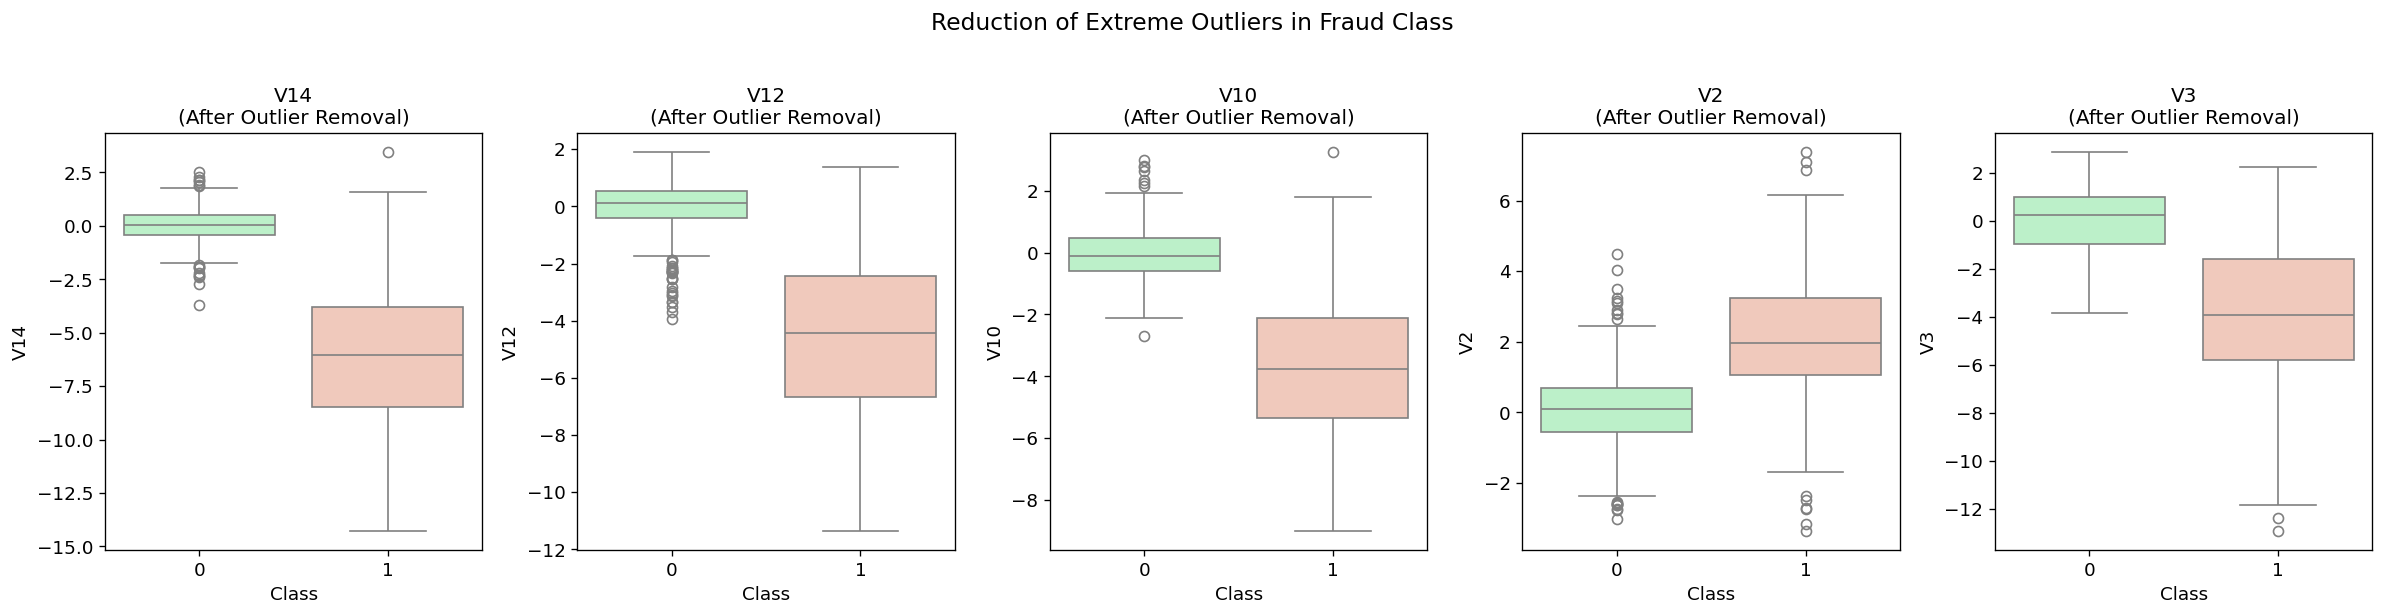

In [16]:
# Visualise outlier reduction for the top 3 features
fig, axes = plt.subplots(1,5, figsize=(20, 5))
for ax, feat in zip(axes, ['V14', 'V12', 'V10', 'V2', 'V3', 'V4', 'V7', 'V9', 'V11', 'V16', 'V17', 'V19']):
    sns.boxplot(x='Class', y=feat, data=underSample_clean, palette=colors, ax=ax)
    ax.set_title(f'{feat}\n(After Outlier Removal)', fontsize=12)
plt.suptitle('Reduction of Extreme Outliers in Fraud Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 11. Dimensionality Reduction & Cluster Visualisation

We apply t-SNE, PCA, and Truncated SVD to visually confirm that the fraud and legitimate classes are separable in the feature space. Strong visual separation is a positive indicator that our classifiers will learn meaningful decision boundaries.

**t-SNE**: Best at revealing local cluster structure; non-linear; computationally expensive  
**PCA**: Linear projection; fast; shows global variance directions  
**Truncated SVD**: Similar to PCA but works on sparse matrices; useful for comparison

In [17]:
# Use df_top23 for dimensionality reduction (broader feature coverage than top12)
top23_features = [
    'scaled_amount', 'scaled_time',
    'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
    'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19',
    'V20', 'V21', 'V27', 'V28'
]
# Build from the clean balanced subsample
df_top23 = underSample_clean[top23_features + ['Class']].dropna()
X_dr = df_top23.drop('Class', axis=1).values
y_dr = df_top23['Class'].values

t0 = time.time()
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_dr)
print(f't-SNE         : {time.time()-t0:.2f}s')

t0 = time.time()
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_dr)
print(f'PCA           : {time.time()-t0:.2f}s')

t0 = time.time()
X_svd = TruncatedSVD(n_components=2, random_state=42).fit_transform(X_dr)
print(f'Truncated SVD : {time.time()-t0:.2f}s')

t-SNE         : 5.77s
PCA           : 0.00s
Truncated SVD : 0.48s


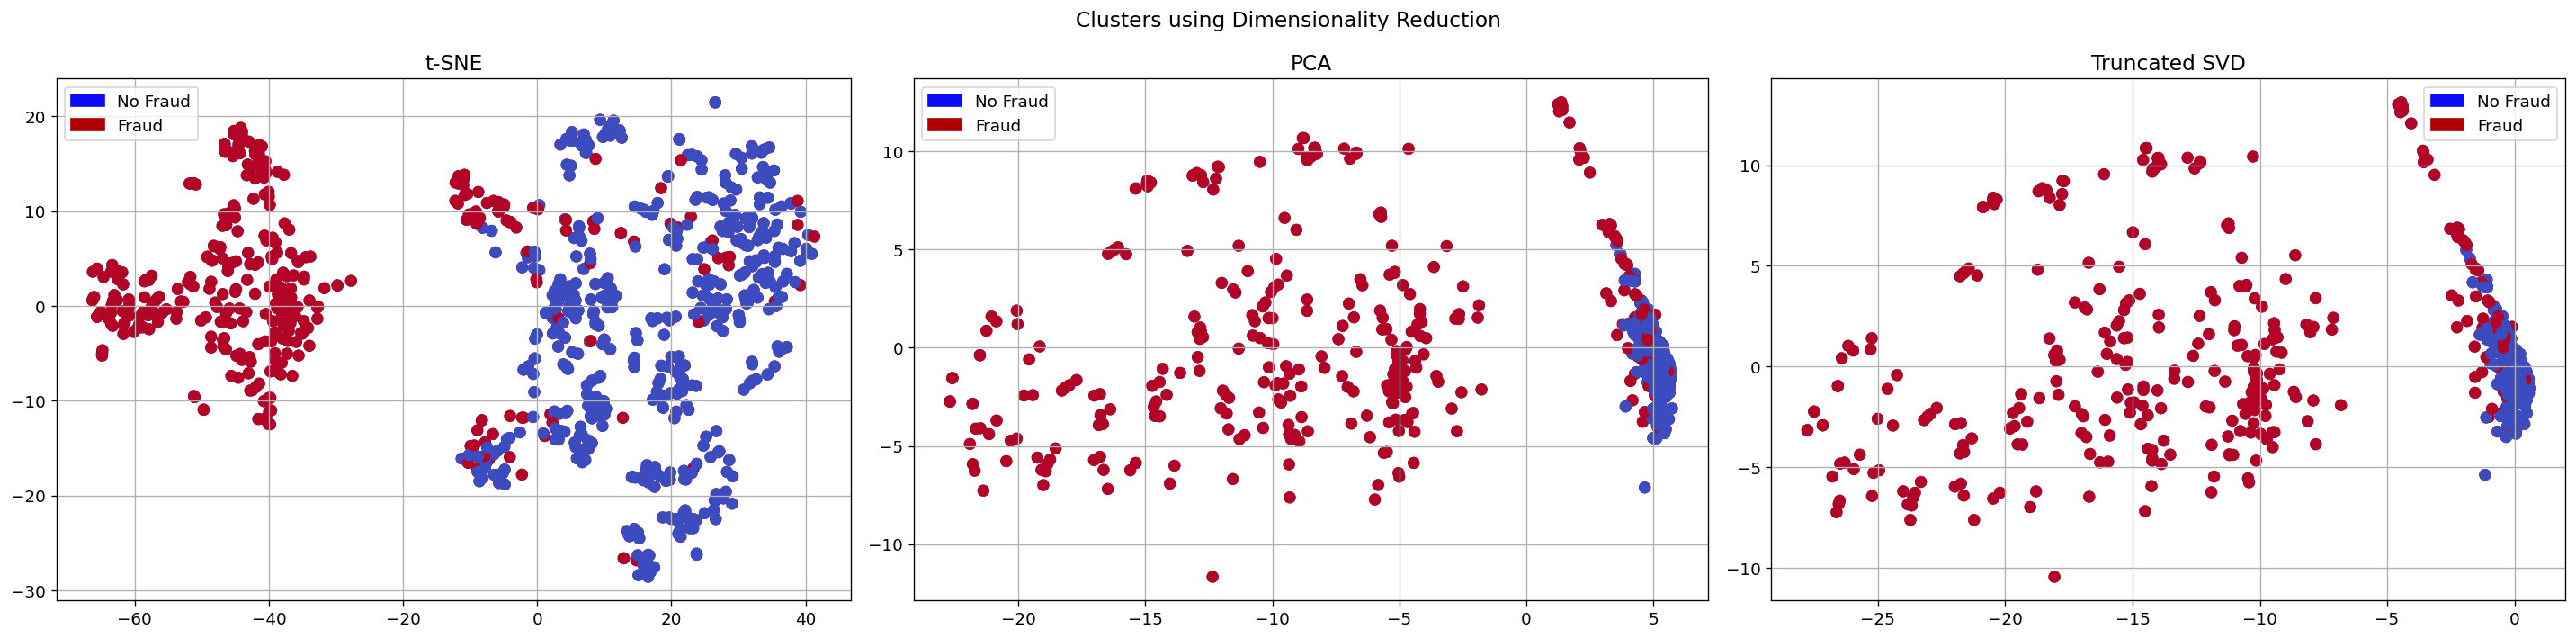

In [18]:
blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch  = mpatches.Patch(color='#AF0000', label='Fraud')

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)

for ax, X_red, title in zip(
    [ax1, ax2, ax3],
    [X_tsne, X_pca, X_svd],
    ['t-SNE', 'PCA', 'Truncated SVD']
):
    ax.scatter(X_red[:, 0], X_red[:, 1], c=(y_dr == 0), cmap='coolwarm', linewidths=2, label='No Fraud')
    ax.scatter(X_red[:, 0], X_red[:, 1], c=(y_dr == 1), cmap='coolwarm', linewidths=2, label='Fraud')
    ax.set_title(title, fontsize=14)
    ax.grid(True)
    ax.legend(handles=[blue_patch, red_patch])

plt.tight_layout()
plt.show()

---
## 12. CLASSICAL ML MODELS — Stratified K-Fold with Undersampling Inside Each Fold

### Pipeline Design
```
Original imbalanced data
        |
  StratifiedKFold split
        |
  [Train fold]  ──→  RandomUnderSampler (inside fold only)
                             |
                       Train model
                             |
  [Val fold]   ←── Evaluate on ORIGINAL distribution (no resampling)
```

**Why undersampling inside the fold?** Applying undersampling before cross-validation is a data leakage risk. The undersampled fold validation set would no longer represent the true test distribution, inflating recall and F1 estimates.  

**Primary metric: PR-AUC (Average Precision)** — at 0.17% fraud rate, PR-AUC is far more discriminative than ROC-AUC. A model that scores ROC-AUC=0.97 but PR-AUC=0.30 is not useful in practice.

In [19]:
X_full = df.drop('Class', axis=1)
y_full = df['Class']

classical_classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'SVM':                 SVC(probability=True, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Naive Bayes':         GaussianNB(),
}

RUS = RandomUnderSampler(random_state=42)
classical_results = {}

for name, clf in classical_classifiers.items():
    fold_pr_auc, fold_roc_auc, fold_f1, fold_recall, fold_precision = [], [], [], [], []

    for train_idx, val_idx in SKF.split(X_full, y_full):
        X_tr, X_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
        y_tr, y_val = y_full.iloc[train_idx], y_full.iloc[val_idx]

        # Undersample inside the fold — prevents leakage
        X_tr_res, y_tr_res = RUS.fit_resample(X_tr, y_tr)

        clf.fit(X_tr_res, y_tr_res)

        if hasattr(clf, 'predict_proba'):
            y_prob = clf.predict_proba(X_val)[:, 1]
        else:
            y_prob = clf.decision_function(X_val)

        y_pred = clf.predict(X_val)

        fold_pr_auc.append(average_precision_score(y_val, y_prob))
        fold_roc_auc.append(roc_auc_score(y_val, y_prob))
        fold_f1.append(f1_score(y_val, y_pred))
        fold_recall.append(recall_score(y_val, y_pred))
        fold_precision.append(precision_score(y_val, y_pred))

    classical_results[name] = {
        'PR-AUC (Avg Precision)': np.mean(fold_pr_auc),
        'ROC-AUC':                np.mean(fold_roc_auc),
        'F1 Score':               np.mean(fold_f1),
        'Recall':                 np.mean(fold_recall),
        'Precision':              np.mean(fold_precision),
    }
    print(f'{name:25s} | PR-AUC={np.mean(fold_pr_auc):.4f} | ROC-AUC={np.mean(fold_roc_auc):.4f} | F1={np.mean(fold_f1):.4f}')

classical_df = pd.DataFrame(classical_results).T.round(4)
classical_df = classical_df.sort_values('PR-AUC (Avg Precision)', ascending=False)
print('\n', classical_df)

Logistic Regression       | PR-AUC=0.7124 | ROC-AUC=0.9770 | F1=0.0928
KNN                       | PR-AUC=0.3328 | ROC-AUC=0.9721 | F1=0.1042
SVM                       | PR-AUC=0.6732 | ROC-AUC=0.9812 | F1=0.1719
Decision Tree             | PR-AUC=0.0146 | ROC-AUC=0.9044 | F1=0.0313
Naive Bayes               | PR-AUC=0.0812 | ROC-AUC=0.9594 | F1=0.1002

                      PR-AUC (Avg Precision)  ROC-AUC  F1 Score  Recall  \
Logistic Regression                  0.7124   0.9770    0.0928  0.9146   
SVM                                  0.6732   0.9812    0.1719  0.8821   
KNN                                  0.3328   0.9721    0.1042  0.8943   
Naive Bayes                          0.0812   0.9594    0.1002  0.8638   
Decision Tree                        0.0146   0.9044    0.0313  0.9065   

                     Precision  
Logistic Regression     0.0489  
SVM                     0.0954  
KNN                     0.0554  
Naive Bayes             0.0533  
Decision Tree           0.0159  


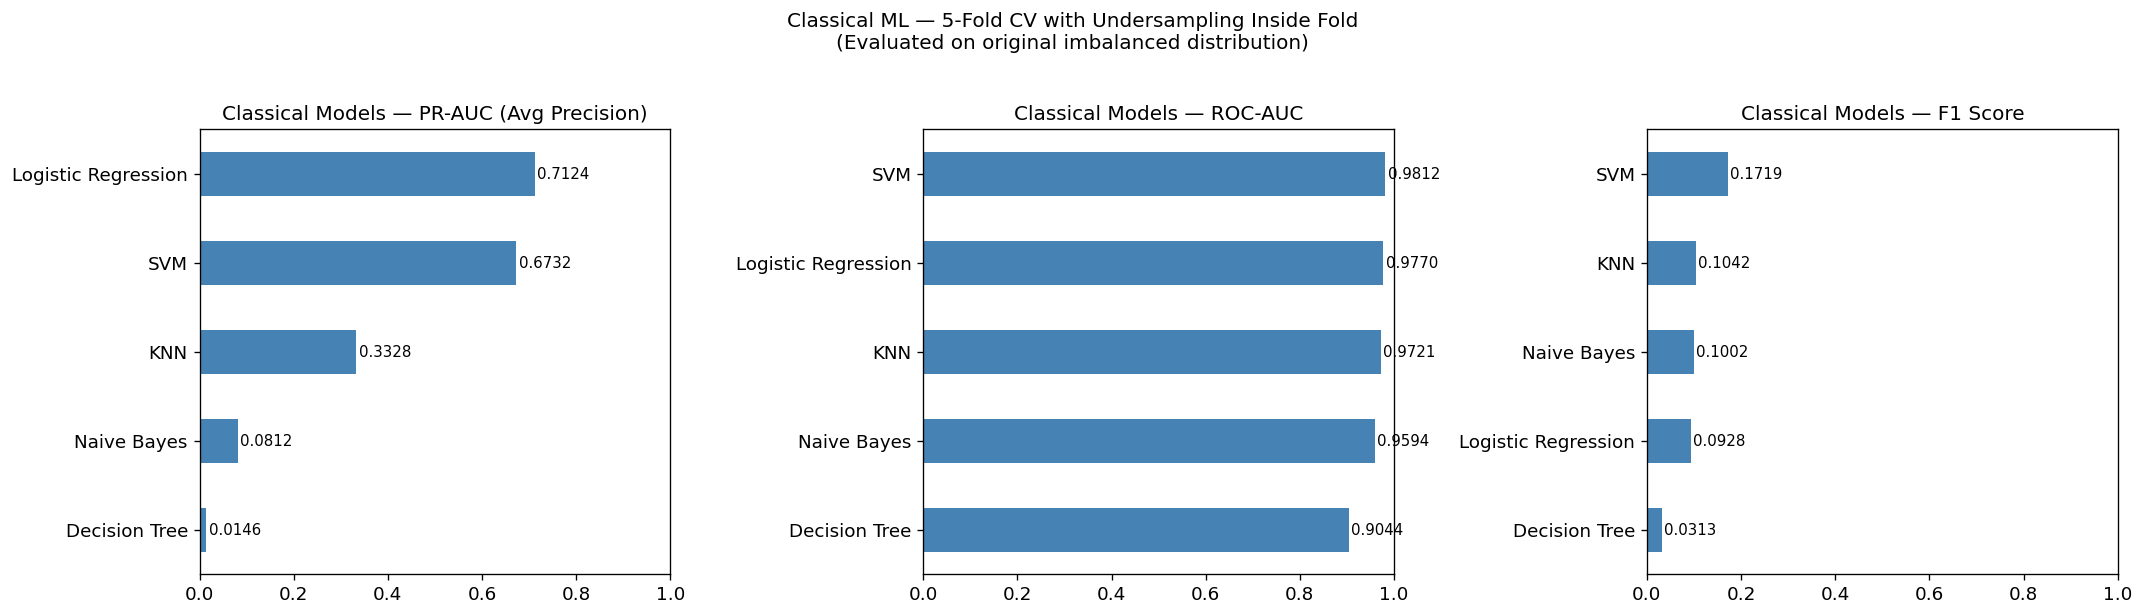

In [20]:
# Visualise classical model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['PR-AUC (Avg Precision)', 'ROC-AUC', 'F1 Score']):
    classical_df[metric].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Classical Models — {metric}', fontsize=12)
    ax.set_xlim(0, 1)
    for i, v in enumerate(classical_df[metric].sort_values()):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Classical ML — 5-Fold CV with Undersampling Inside Fold\n(Evaluated on original imbalanced distribution)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 13. Classical Models — Learning Curves

Learning curves help diagnose **bias vs variance**:  
- **Large gap** between training and CV score → high variance (overfitting)  
- **Both curves low** → high bias (underfitting)  
- **Curves converge** → well-fitted model  

We fit learning curves on the **balanced subsample** to get meaningful curves — using the full imbalanced dataset would produce misleading accuracy-dominated results.

In [21]:
# Retrain classical models on balanced subsample for learning curve analysis
X_us = underSample_clean.drop('Class', axis=1).values
y_us = underSample_clean['Class'].values

# Best estimators from grid-searched parameters (refit for curves)
from sklearn.model_selection import GridSearchCV

log_reg = GridSearchCV(
    LogisticRegression(max_iter=1000),
    {'C': [0.001, 0.01, 0.1, 1, 10], 'penalty': ['l2']},
    cv=5, scoring='f1'
).fit(X_us, y_us).best_estimator_

knears = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 9]},
    cv=5, scoring='f1'
).fit(X_us, y_us).best_estimator_

svc_clf = GridSearchCV(
    SVC(probability=True),
    {'C': [0.5, 1, 5], 'kernel': ['rbf', 'linear']},
    cv=5, scoring='f1'
).fit(X_us, y_us).best_estimator_

tree_clf = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [3, 5, 7], 'min_samples_leaf': [3, 5, 7]},
    cv=5, scoring='f1'
).fit(X_us, y_us).best_estimator_

print('GridSearchCV complete — best parameters found:')
print(f'  LogReg : C={log_reg.C}, penalty={log_reg.penalty}')
print(f'  KNN    : n_neighbors={knears.n_neighbors}')
print(f'  SVC    : C={svc_clf.C}, kernel={svc_clf.kernel}')
print(f'  DTree  : max_depth={tree_clf.max_depth}, min_samples_leaf={tree_clf.min_samples_leaf}')

GridSearchCV complete — best parameters found:
  LogReg : C=0.01, penalty=l2
  KNN    : n_neighbors=3
  SVC    : C=5, kernel=rbf
  DTree  : max_depth=5, min_samples_leaf=7


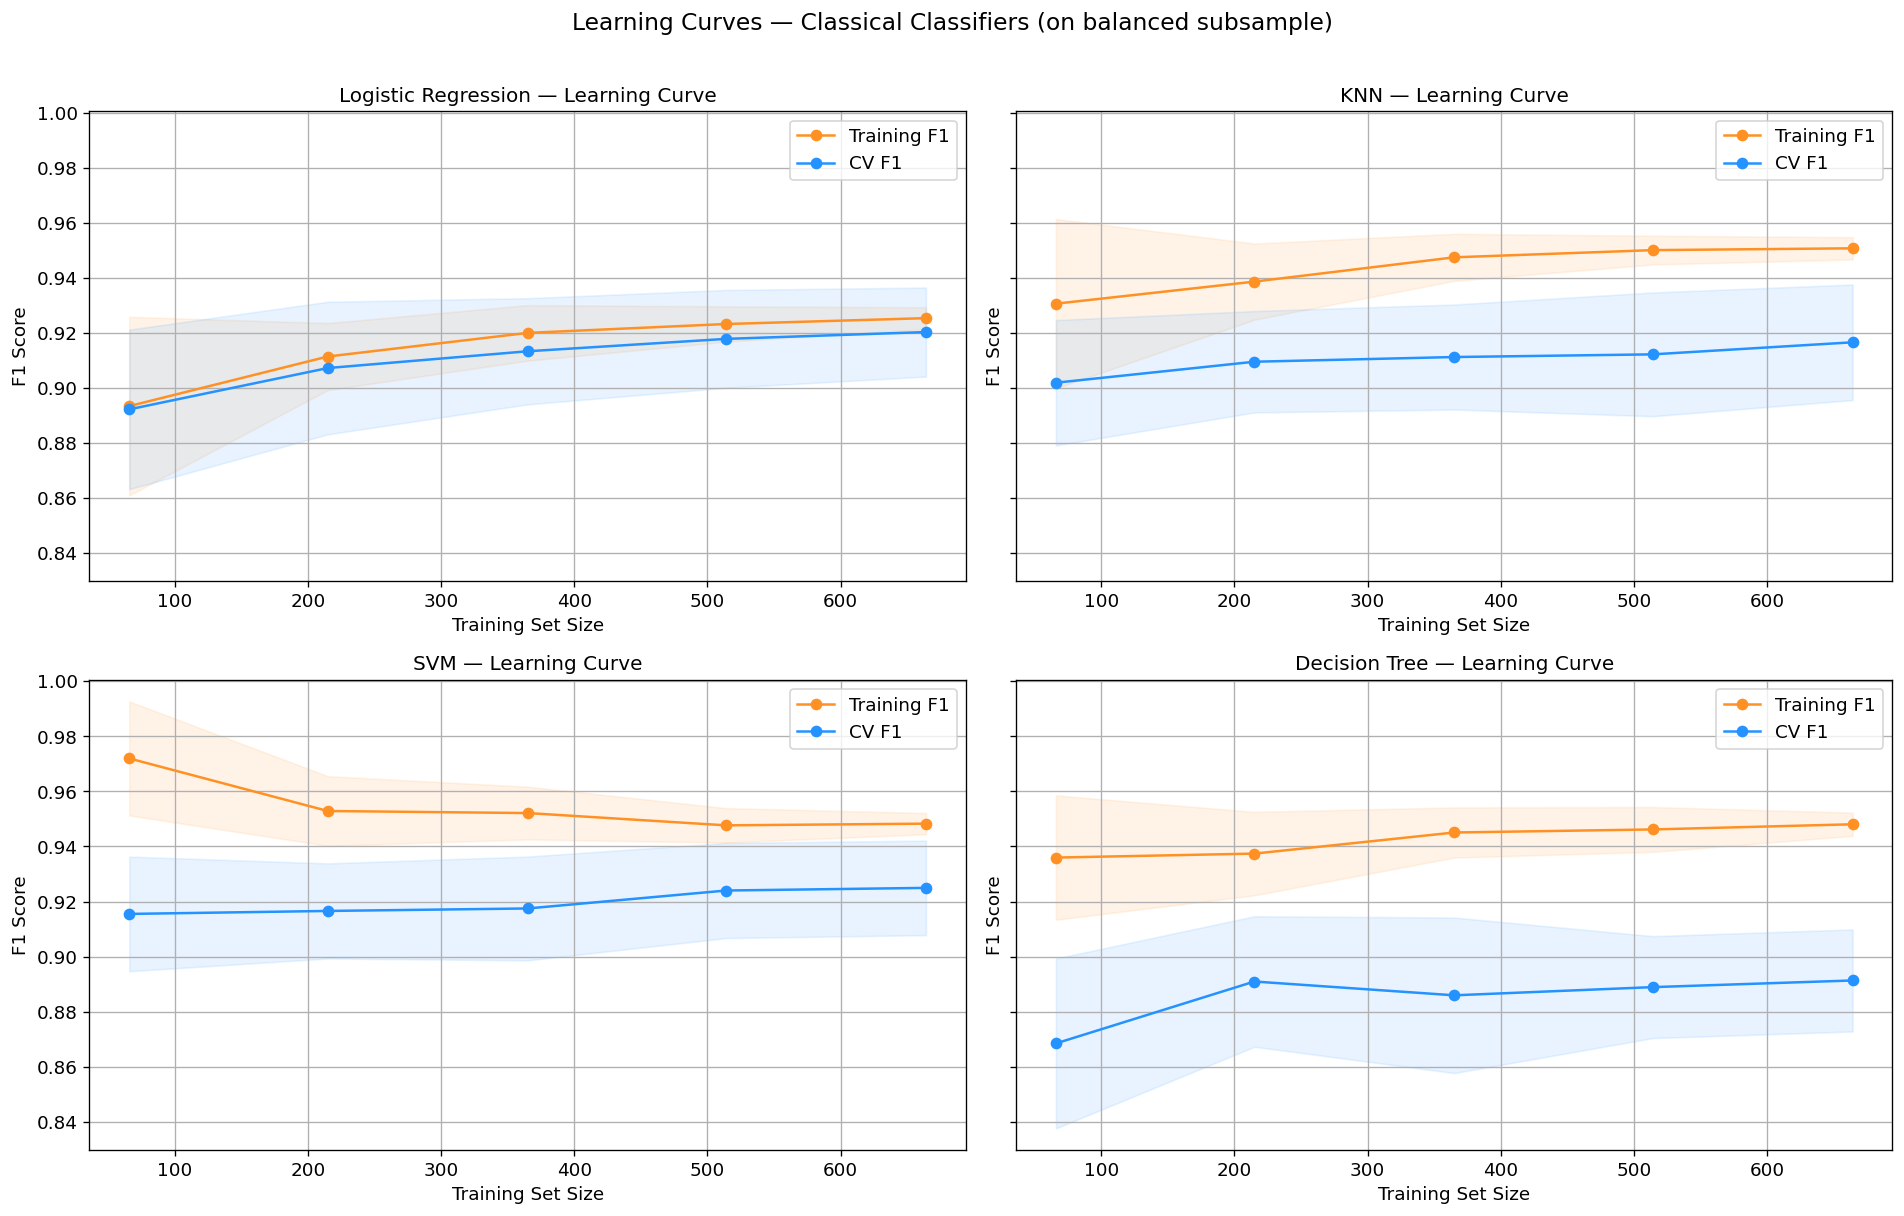

In [22]:
def plot_learning_curves(estimators, names, X, y, cv, train_sizes=np.linspace(.1, 1.0, 5)):
    n = len(estimators)
    cols = 2
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), sharey=True)
    axes = axes.flatten()

    for i, (est, name) in enumerate(zip(estimators, names)):
        train_sz, train_sc, test_sc = learning_curve(
            est, X, y, cv=cv, n_jobs=-1,
            train_sizes=train_sizes, scoring='f1'
        )
        tr_mean, tr_std = train_sc.mean(1), train_sc.std(1)
        te_mean, te_std = test_sc.mean(1),  test_sc.std(1)

        axes[i].fill_between(train_sz, tr_mean - tr_std, tr_mean + tr_std, alpha=0.1, color='#ff9124')
        axes[i].fill_between(train_sz, te_mean - te_std, te_mean + te_std, alpha=0.1, color='#2492ff')
        axes[i].plot(train_sz, tr_mean, 'o-', color='#ff9124', label='Training F1')
        axes[i].plot(train_sz, te_mean, 'o-', color='#2492ff', label='CV F1')
        axes[i].set_title(f'{name} — Learning Curve', fontsize=12)
        axes[i].set_xlabel('Training Set Size')
        axes[i].set_ylabel('F1 Score')
        axes[i].legend(loc='best')
        axes[i].grid(True)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Learning Curves — Classical Classifiers (on balanced subsample)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

cv_lc = ShuffleSplit(n_splits=20, test_size=0.2, random_state=42)
plot_learning_curves(
    [log_reg, knears, svc_clf, tree_clf],
    ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree'],
    X_us, y_us, cv_lc
)

---
## 14. ROC Curves — Classical Models

ROC curves are plotted on the **balanced subsample** training data to visualise discriminative power. Note that ROC-AUC results here are optimistic because the balanced subsample gives equal weight to both classes — the PR-AUC results on the original imbalanced data (Section 12) are the more honest metric.

In [71]:
from sklearn.model_selection import cross_val_predict

X_tr_split, X_te_split, y_tr_split, y_te_split = train_test_split(
    X_us, y_us, test_size=0.2, random_state=42, stratify=y_us
)

log_reg_pred  = cross_val_predict(log_reg,  X_tr_split, y_tr_split, cv=5, method='decision_function')
knears_pred   = cross_val_predict(knears,   X_tr_split, y_tr_split, cv=5)
svc_pred      = cross_val_predict(svc_clf,  X_tr_split, y_tr_split, cv=5, method='decision_function')
tree_pred     = cross_val_predict(tree_clf, X_tr_split, y_tr_split, cv=5)

print('ROC-AUC on balanced subsample CV predictions:')
for name, pred in [('Logistic Regression', log_reg_pred),
                   ('KNN', knears_pred),
                   ('SVM', svc_pred),
                   ('Decision Tree', tree_pred)]:
    print(f'  {name:25s}: {roc_auc_score(y_tr_split, pred):.4f}')

ROC-AUC on balanced subsample CV predictions:
  Logistic Regression      : 0.9714
  KNN                      : 0.9184
  SVM                      : 0.9706
  Decision Tree            : 0.9052


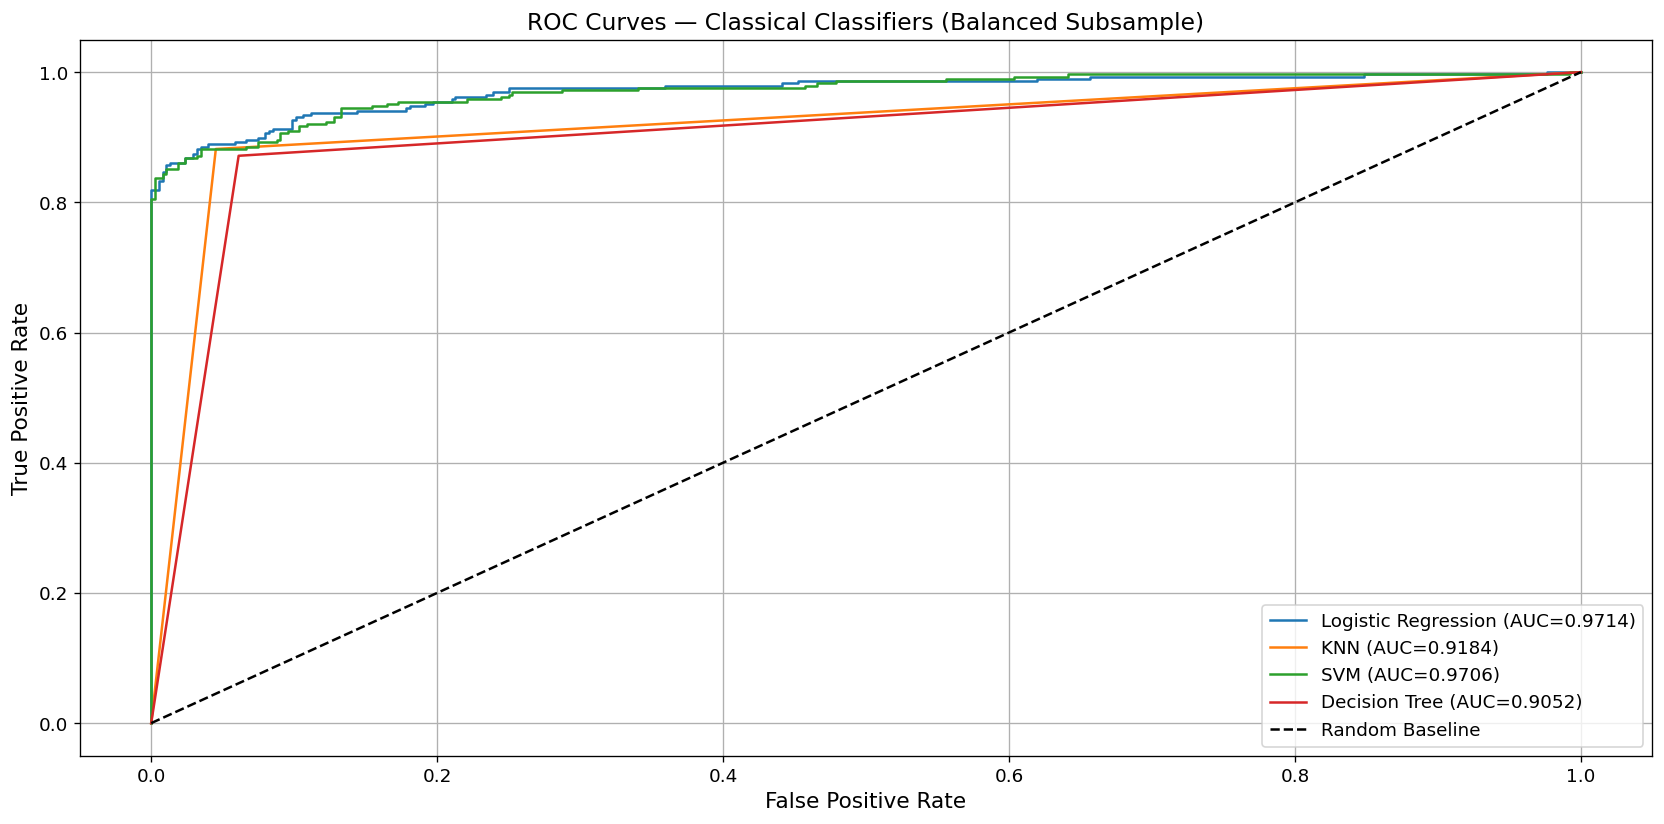

In [72]:
plt.figure(figsize=(14, 7))
plt.title('ROC Curves — Classical Classifiers (Balanced Subsample)', fontsize=14)

for name, pred in [('Logistic Regression', log_reg_pred),
                   ('KNN', knears_pred),
                   ('SVM', svc_pred),
                   ('Decision Tree', tree_pred)]:
    fpr, tpr, _ = roc_curve(y_tr_split, pred)
    auc_val = roc_auc_score(y_tr_split, pred)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

---
## 15. SMOTE Inside Cross-Validation — Oversampling Approach

**SMOTE (Synthetic Minority Over-Sampling Technique)** generates synthetic minority class samples by interpolating between existing fraud samples. Unlike random undersampling, SMOTE preserves all legitimate transaction data.

**Critical implementation note:** SMOTE is applied **inside each fold** using imblearn's Pipeline. If SMOTE is applied before splitting, synthetic samples may appear in both train and validation folds — a severe data leakage that produces artificially inflated scores.

In [ ]:
smote_results = {}

smote_classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
}

for name, clf in smote_classifiers.items():
    # imblearn Pipeline: SMOTE runs inside each fold, never on validation set
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   clf)
    ])

    pr_scores  = cross_val_score(pipe, X_full, y_full, cv=SKF, scoring='average_precision')
    roc_scores = cross_val_score(pipe, X_full, y_full, cv=SKF, scoring='roc_auc')
    f1_scores  = cross_val_score(pipe, X_full, y_full, cv=SKF, scoring='f1')

    smote_results[name] = {
        'PR-AUC':   np.mean(pr_scores),
        'ROC-AUC':  np.mean(roc_scores),
        'F1 Score': np.mean(f1_scores),
    }
    print(f'{name:25s} | PR-AUC={np.mean(pr_scores):.4f} | ROC-AUC={np.mean(roc_scores):.4f} | F1={np.mean(f1_scores):.4f}')

smote_df = pd.DataFrame(smote_results).T.round(4).sort_values('PR-AUC', ascending=False)
print('\nSMOTE Results (SMOTE inside CV fold):')
print(smote_df)

Logistic Regression       | PR-AUC=0.7407 | ROC-AUC=0.9781 | F1=0.1127


---
## 16. Confusion Matrices — Classical Models on Hold-Out Test Set

Final confusion matrices on the **original imbalanced test set** (never seen during training). This is the honest evaluation.

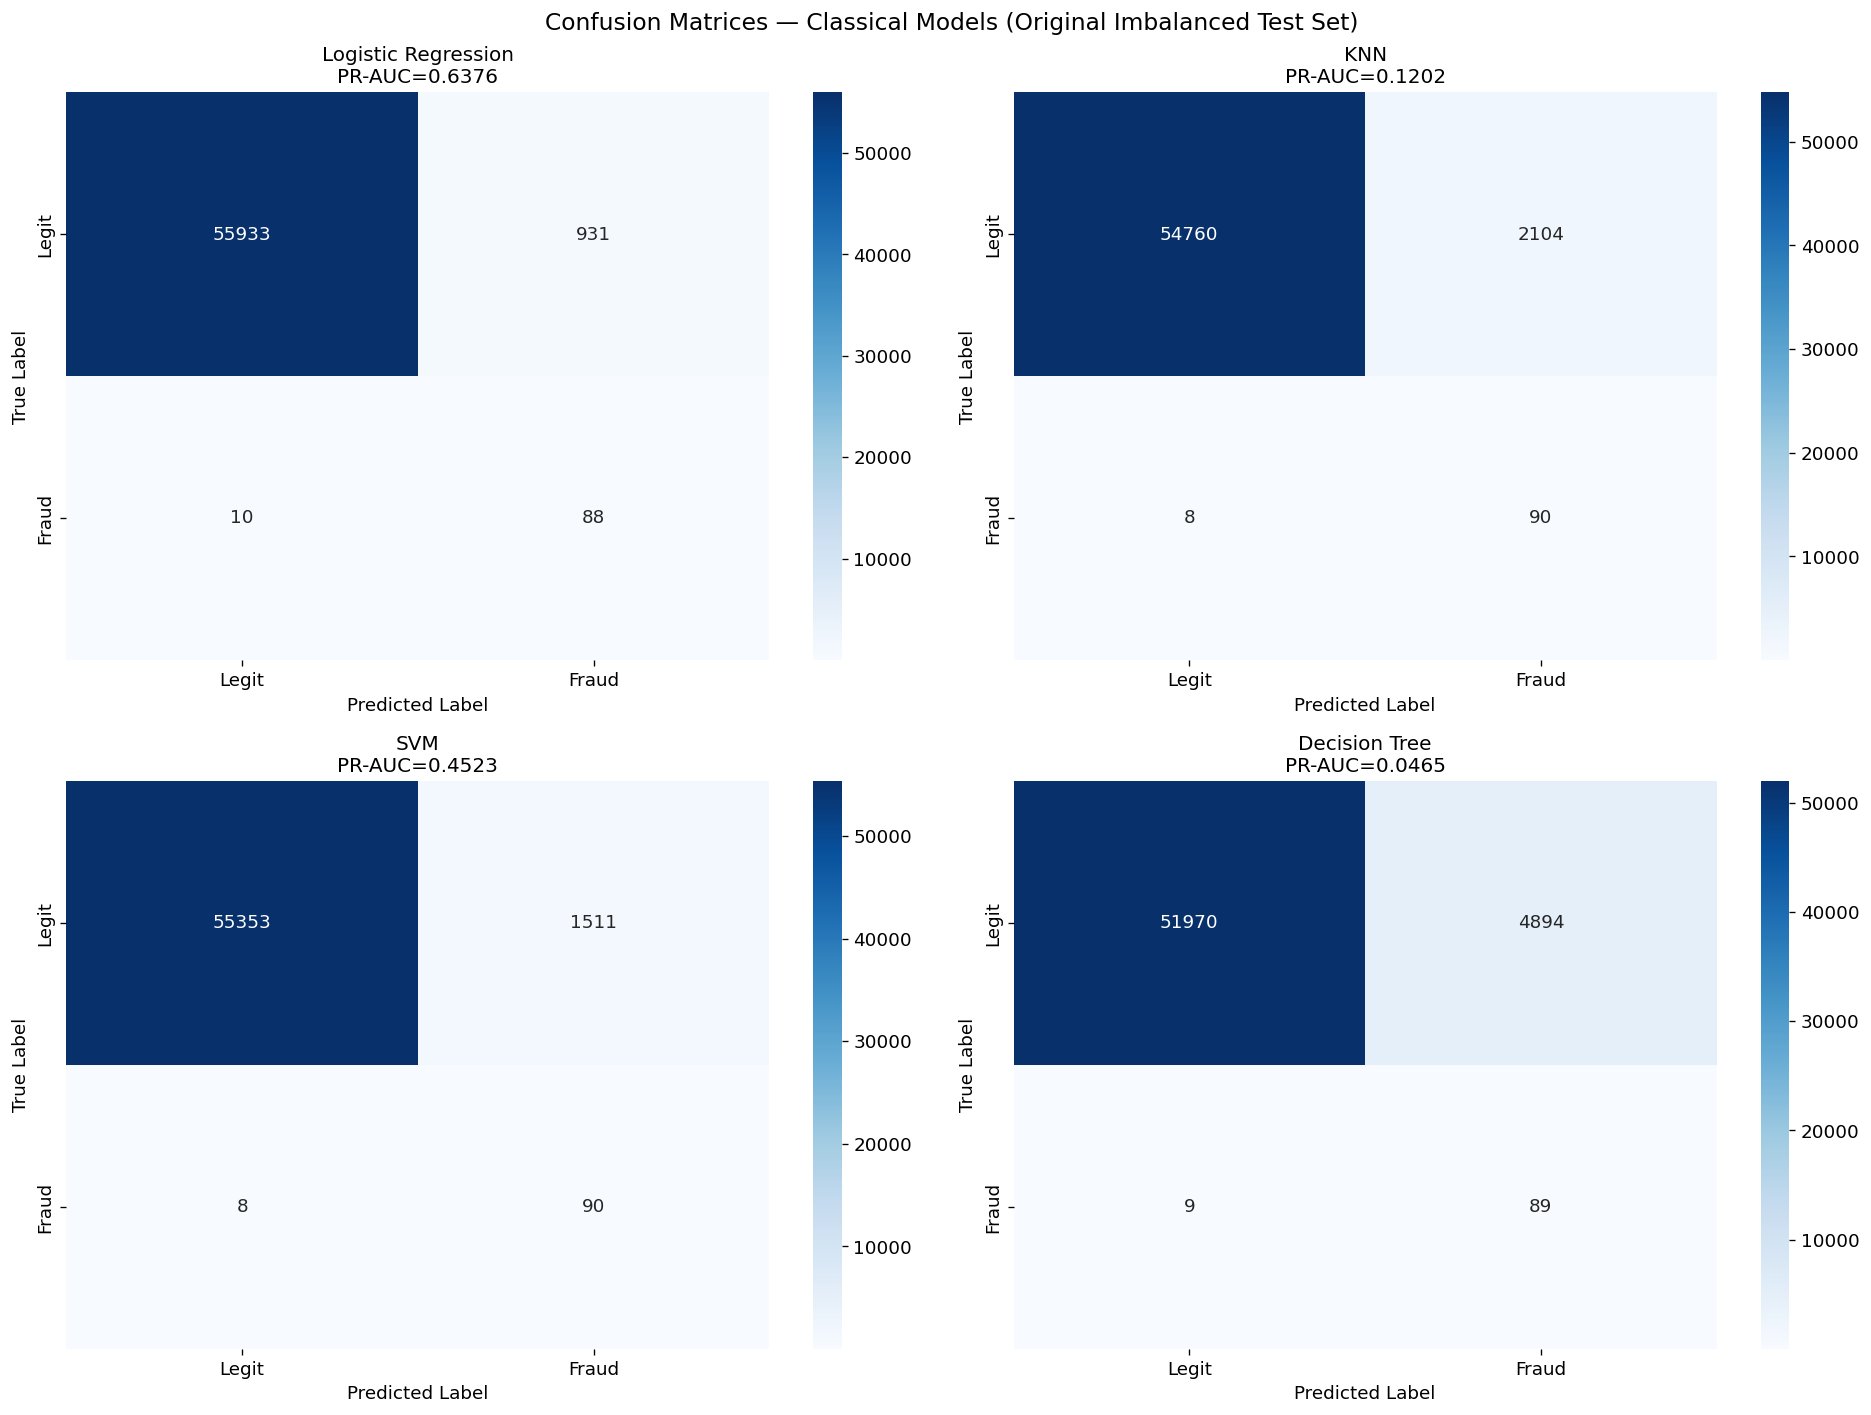

In [25]:
# Retrain classical best-estimators on full training set with undersampling
X_tr_res, y_tr_res = RUS.fit_resample(X_train_orig, y_train_orig)

classical_final = {
    'Logistic Regression': log_reg,
    'KNN':                 knears,
    'SVM':                 svc_clf,
    'Decision Tree':       tree_clf,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (name, clf) in zip(axes.flatten(), classical_final.items()):
    clf.fit(X_tr_res, y_tr_res)
    y_pred = clf.predict(X_test_orig)
    cm = confusion_matrix(y_test_orig, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax.set_title(f'{name}\nPR-AUC={average_precision_score(y_test_orig, clf.predict_proba(X_test_orig)[:, 1] if hasattr(clf, "predict_proba") else clf.decision_function(X_test_orig)):.4f}', fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — Classical Models (Original Imbalanced Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 17. ENSEMBLE MODELS

Ensemble methods combine multiple learners to produce better predictions than any single model. This section evaluates:

| Model | Imbalance Strategy | Type |
|---|---|---|
| **Random Forest** (standard) | `class_weight='balanced'` | Parallel (bagging) |
| **Balanced Random Forest** | Bootstrap undersample each tree | Parallel (bagging) |
| **Balanced Bagging** | Undersample per bag | Parallel (bagging) |
| **Self-Paced Ensemble** | Progressive undersampling (easy→hard majority samples) | Iterative ensemble |
| **XGBoost** | `scale_pos_weight=IR` | Iterative (boosting) |
| **LightGBM** | `class_weight='balanced'` | Iterative (boosting) |

### Why these ensemble strategies?
- **Balanced Random Forest (BRF):** Each tree in the forest is trained on a bootstrap sample where the minority class is fully represented and the majority class is undersampled to match. This integrates resampling directly into the ensemble architecture.
- **BalancedBagging:** Wraps any base estimator, applying random undersampling within each bootstrap sample — a generalisation of BRF.
- **Self-Paced Ensemble:** Trains multiple learners while gradually increasing majority-class difficulty, often improving minority detection stability over plain random undersampling.
- **Weighted XGBoost (`scale_pos_weight`):** XGBoost's boosting mechanism assigns higher gradient contributions to misclassified minority instances. Setting `scale_pos_weight = IR` directly encodes the cost ratio into the loss function.

In [42]:
# Optional dependency for Self-Paced Ensemble
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('imbens') is None:
    print('Installing imbalanced-ensemble for Self-Paced Ensemble...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-ensemble'])
else:
    print('imbalanced-ensemble is already installed.')

Installing imbalanced-ensemble for Self-Paced Ensemble...


In [43]:
# Imbalance Ratio used as cost weight for gradient boosters
IR_val = float(y_full.value_counts()[0]) / float(y_full.value_counts()[1])
print(f'Imbalance Ratio: {IR_val:.2f}')

# Optional: Self-Paced Ensemble (undersampling ensemble) from imbalanced-ensemble
try:
    SelfPacedEnsembleClassifier = __import__(
        'imbens.ensemble', fromlist=['SelfPacedEnsembleClassifier']
    ).SelfPacedEnsembleClassifier
    has_self_paced = True
except Exception:
    has_self_paced = False
    print("SelfPacedEnsemble not available. Install with: pip install imbalanced-ensemble")

ensemble_classifiers = {
    'Random Forest (balanced cw)':    RandomForestClassifier(
                                          n_estimators=200,
                                          class_weight='balanced',
                                          random_state=42, n_jobs=-1),

    'Balanced Random Forest':         BalancedRandomForestClassifier(
                                          n_estimators=200,
                                          random_state=42, n_jobs=-1),

    'Balanced Bagging':               BalancedBaggingClassifier(
                                          estimator=DecisionTreeClassifier(max_depth=7),
                                          n_estimators=100,
                                          random_state=42, n_jobs=-1),

    'XGBoost (scale_pos_weight)':     XGBClassifier(
                                          n_estimators=300,
                                          scale_pos_weight=IR_val,   # cost-sensitive weight
                                          use_label_encoder=False,
                                          eval_metric='logloss',
                                          random_state=42, n_jobs=-1),

    'LightGBM (balanced cw)':         LGBMClassifier(
                                          n_estimators=300,
                                          class_weight='balanced',
                                          random_state=42, n_jobs=-1),
}

if has_self_paced:
    ensemble_classifiers['Self-Paced Ensemble'] = SelfPacedEnsembleClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

ensemble_results = {}

for name, clf in ensemble_classifiers.items():
    fold_pr, fold_roc, fold_f1, fold_rec, fold_prec = [], [], [], [], []

    for train_idx, val_idx in SKF.split(X_full, y_full):
        X_tr, X_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
        y_tr, y_val = y_full.iloc[train_idx], y_full.iloc[val_idx]

        clf.fit(X_tr, y_tr)
        y_prob = clf.predict_proba(X_val)[:, 1]
        y_pred = clf.predict(X_val)

        fold_pr.append(average_precision_score(y_val, y_prob))
        fold_roc.append(roc_auc_score(y_val, y_prob))
        fold_f1.append(f1_score(y_val, y_pred))
        fold_rec.append(recall_score(y_val, y_pred))
        fold_prec.append(precision_score(y_val, y_pred))

    ensemble_results[name] = {
        'PR-AUC (Avg Precision)': np.mean(fold_pr),
        'ROC-AUC':                np.mean(fold_roc),
        'F1 Score':               np.mean(fold_f1),
        'Recall':                 np.mean(fold_rec),
        'Precision':              np.mean(fold_prec),
    }
    print(f'{name:40s} | PR-AUC={np.mean(fold_pr):.4f} | ROC-AUC={np.mean(fold_roc):.4f} | F1={np.mean(fold_f1):.4f} | Recall={np.mean(fold_rec):.4f}')

ensemble_df = pd.DataFrame(ensemble_results).T.round(4)
ensemble_df = ensemble_df.sort_values('PR-AUC (Avg Precision)', ascending=False)
print('\n', ensemble_df)

Imbalance Ratio: 577.88
Random Forest (balanced cw)              | PR-AUC=0.8532 | ROC-AUC=0.9582 | F1=0.8560 | Recall=0.7724
Balanced Random Forest                   | PR-AUC=0.7830 | ROC-AUC=0.9797 | F1=0.2425 | Recall=0.8841


Imbalance Ratio: 577.88
Random Forest (balanced cw)              | PR-AUC=0.8532 | ROC-AUC=0.9582 | F1=0.8560 | Recall=0.7724
Balanced Random Forest                   | PR-AUC=0.7830 | ROC-AUC=0.9797 | F1=0.2425 | Recall=0.8841


TypeError: _parallel_build_estimators() got multiple values for argument 'verbose'

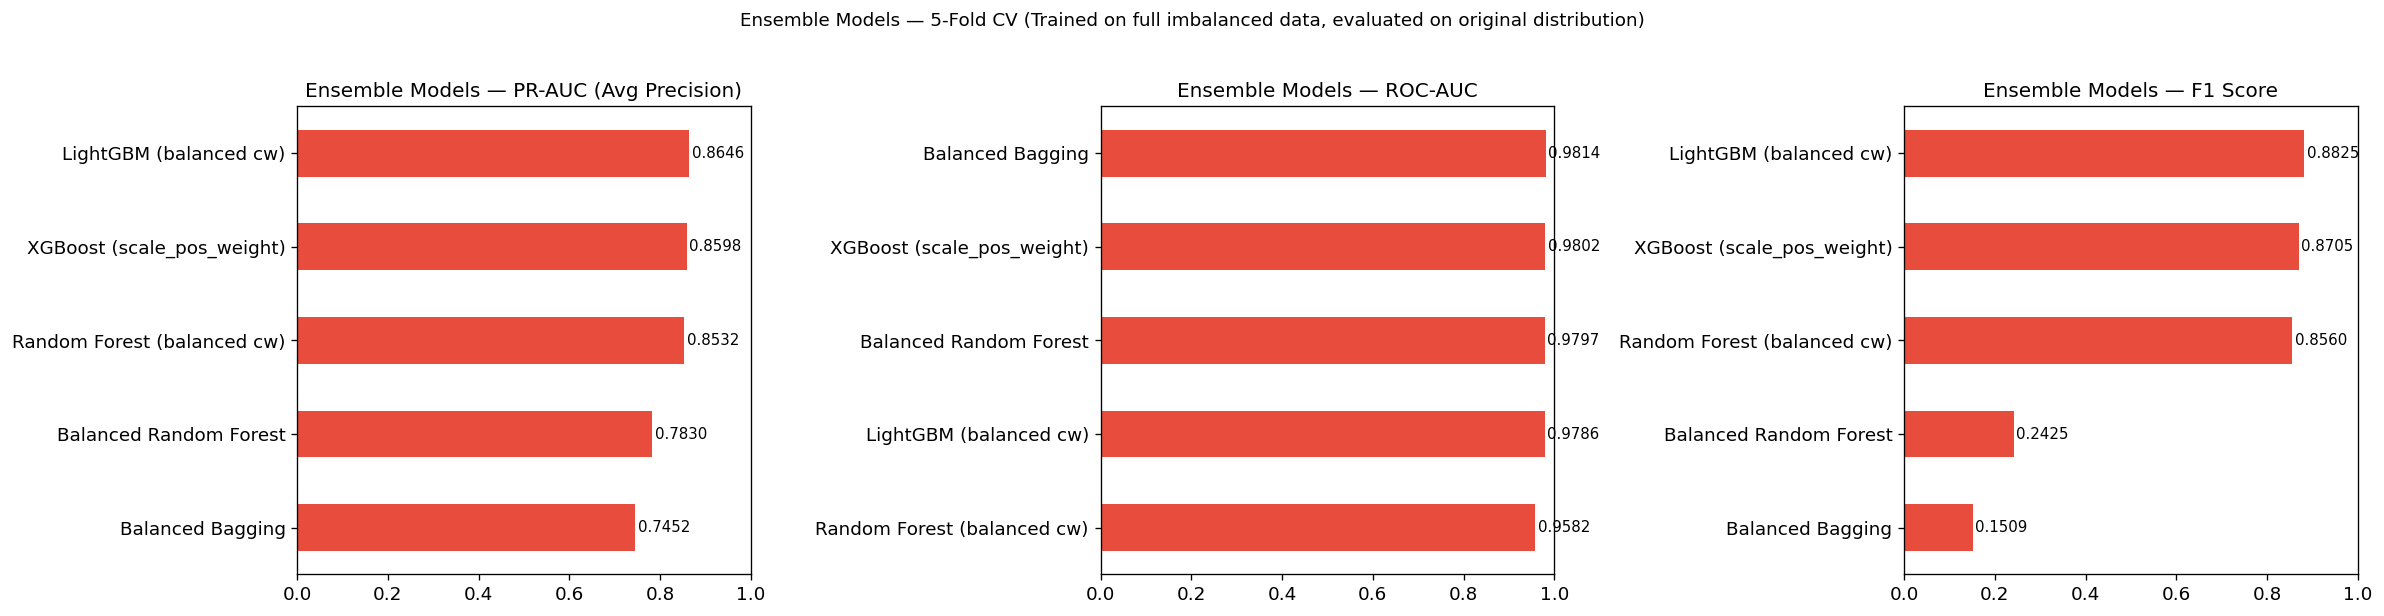

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, metric in zip(axes, ['PR-AUC (Avg Precision)', 'ROC-AUC', 'F1 Score']):
    ensemble_df[metric].sort_values().plot(kind='barh', ax=ax, color='#E74C3C')
    ax.set_title(f'Ensemble Models — {metric}', fontsize=12)
    ax.set_xlim(0, 1)
    for i, v in enumerate(ensemble_df[metric].sort_values()):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Ensemble Models — 5-Fold CV (Trained on full imbalanced data, evaluated on original distribution)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## 18. Feature Importance — Ensemble Models

Tree-based ensemble models provide built-in feature importance via mean decrease in impurity. This helps understand **which features drive fraud detection** and validates our earlier correlation/MI-based feature selection.

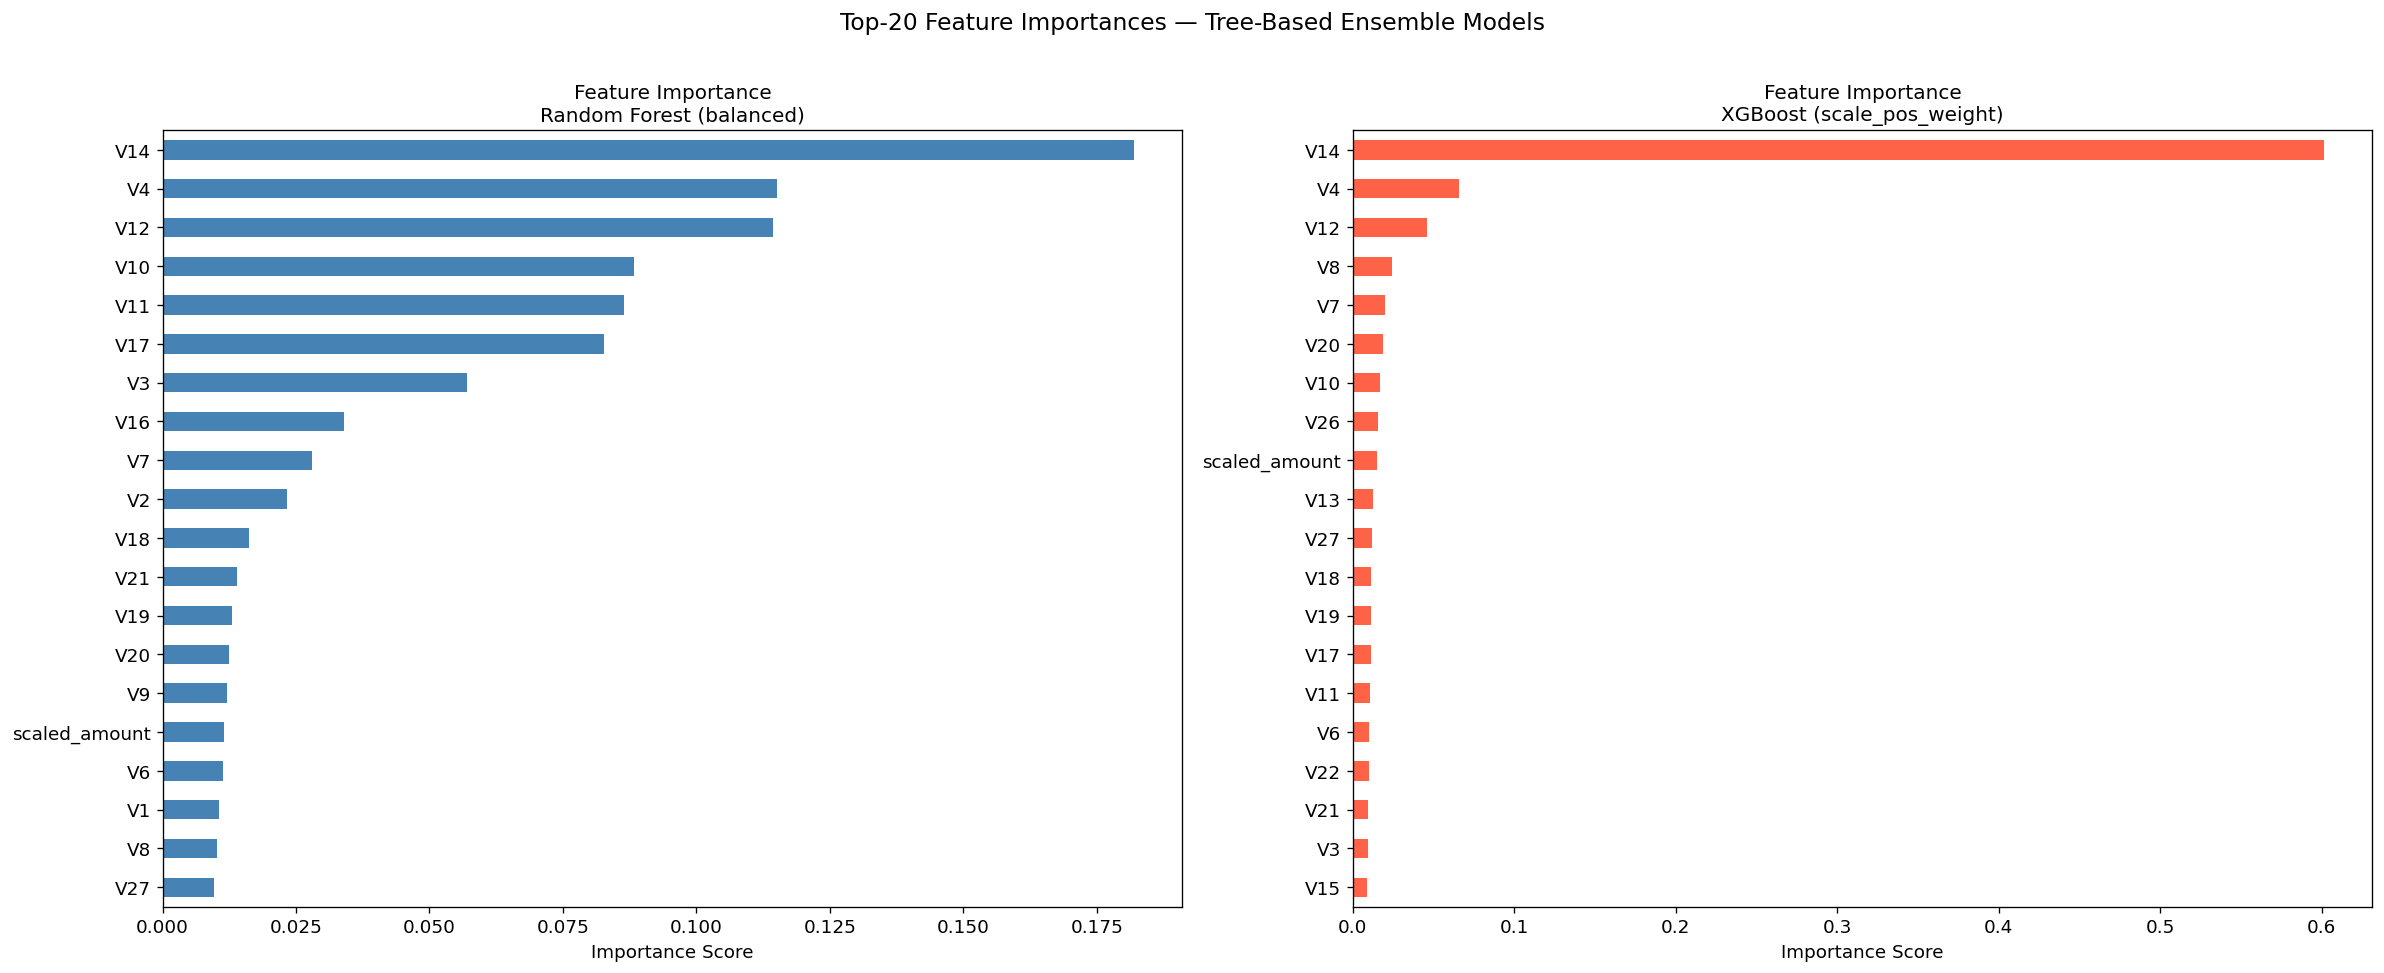

In [28]:
# Fit on the full training set for feature importance
rf_fi = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_fi.fit(X_train_orig, y_train_orig)

xgb_fi = XGBClassifier(n_estimators=300, scale_pos_weight=IR_val, use_label_encoder=False,
                        eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_fi.fit(X_train_orig, y_train_orig)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, model, title, color in zip(
    axes,
    [rf_fi, xgb_fi],
    ['Random Forest (balanced)', 'XGBoost (scale_pos_weight)'],
    ['steelblue', 'tomato']
):
    importances = pd.Series(model.feature_importances_, index=X_full.columns)
    importances.sort_values().tail(20).plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Feature Importance\n{title}', fontsize=12)
    ax.set_xlabel('Importance Score')

plt.suptitle('Top-20 Feature Importances — Tree-Based Ensemble Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 19. COST-SENSITIVE LEARNING

### Theoretical Background
Cost-sensitive learning directly incorporates misclassification costs into the model training process.  
For fraud detection, the cost matrix is asymmetric:

| | Predicted Legit | Predicted Fraud |
|---|---|---|
| **True Legit**  | 0 (correct) | c₀₁ = 1 (false alarm) |
| **True Fraud**  | c₁₀ = IR (missed fraud!) | 0 (correct) |

Using the **Imbalance Ratio (IR)** as the cost for a false negative is a principled heuristic:  
- It balances total cost across both classes: `IR × |fraud| ≈ |legit|`  
- It has a natural business interpretation: missing one fraud costs IR times more than a false alarm  
- It can be treated as a hyperparameter and tuned via model selection

In sklearn, this is implemented via `class_weight={0: 1, 1: IR}` for most classifiers,  
and via `scale_pos_weight=IR` for XGBoost.

### Three Cost-Sensitive Approaches Evaluated
1. **class_weight='balanced'** — sklearn computes weights as n_samples / (n_classes × class_count)  
2. **class_weight={0:1, 1:IR}** — explicit IR-based cost assignment  
3. **Threshold Optimisation** — adjust the decision boundary post-training to maximise recall or minimise total cost

In [29]:
print(f'Imbalance Ratio (IR): {IR_val:.2f}')
print(f'class_weight=(0:1, 1:{IR_val:.0f}) means a missed fraud costs {IR_val:.0f}x a false alarm')

cost_sensitive_classifiers = {
    # Logistic Regression variants
    'LR — no weight':        LogisticRegression(max_iter=1000, random_state=42),
    'LR — balanced':         LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'LR — IR weight':        LogisticRegression(max_iter=1000,
                                                class_weight={0: 1, 1: int(IR_val)}, random_state=42),

    # Decision Tree variants
    'DT — no weight':        DecisionTreeClassifier(random_state=42),
    'DT — balanced':         DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'DT — IR weight':        DecisionTreeClassifier(class_weight={0: 1, 1: int(IR_val)}, random_state=42),

    # Random Forest variants
    'RF — no weight':        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'RF — balanced':         RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                    random_state=42, n_jobs=-1),
    'RF — IR weight':        RandomForestClassifier(n_estimators=200,
                                                    class_weight={0: 1, 1: int(IR_val)},
                                                    random_state=42, n_jobs=-1),

    # XGBoost — scale_pos_weight = IR
    'XGB — no weight':       XGBClassifier(n_estimators=300, use_label_encoder=False,
                                           eval_metric='logloss', random_state=42, n_jobs=-1),
    'XGB — scale_pos_weight': XGBClassifier(n_estimators=300, scale_pos_weight=IR_val,
                                             use_label_encoder=False, eval_metric='logloss',
                                             random_state=42, n_jobs=-1),

    # LightGBM
    'LGBM — balanced':       LGBMClassifier(n_estimators=300, class_weight='balanced',
                                            random_state=42, n_jobs=-1),
    'LGBM — IR weight':      LGBMClassifier(n_estimators=300,
                                            class_weight={0: 1, 1: int(IR_val)},
                                            random_state=42, n_jobs=-1),
}

cs_results = {}

for name, clf in cost_sensitive_classifiers.items():
    fold_pr, fold_roc, fold_f1, fold_rec = [], [], [], []

    for train_idx, val_idx in SKF.split(X_full, y_full):
        X_tr, X_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
        y_tr, y_val = y_full.iloc[train_idx], y_full.iloc[val_idx]

        clf.fit(X_tr, y_tr)
        y_prob = clf.predict_proba(X_val)[:, 1]
        y_pred = clf.predict(X_val)

        fold_pr.append(average_precision_score(y_val, y_prob))
        fold_roc.append(roc_auc_score(y_val, y_prob))
        fold_f1.append(f1_score(y_val, y_pred))
        fold_rec.append(recall_score(y_val, y_pred))

    cs_results[name] = {
        'PR-AUC':  np.mean(fold_pr),
        'ROC-AUC': np.mean(fold_roc),
        'F1':      np.mean(fold_f1),
        'Recall':  np.mean(fold_rec),
    }
    print(f'{name:35s} | PR-AUC={np.mean(fold_pr):.4f} | F1={np.mean(fold_f1):.4f} | Recall={np.mean(fold_rec):.4f}')

cs_df = pd.DataFrame(cs_results).T.round(4).sort_values('PR-AUC', ascending=False)
print('\n', cs_df)

Imbalance Ratio (IR): 577.88
class_weight=(0:1, 1:578) means a missed fraud costs 578x a false alarm
LR — no weight                      | PR-AUC=0.7563 | F1=0.7301 | Recall=0.6261
LR — balanced                       | PR-AUC=0.7292 | F1=0.1215 | Recall=0.9126
LR — IR weight                      | PR-AUC=0.7291 | F1=0.1216 | Recall=0.9126
DT — no weight                      | PR-AUC=0.5876 | F1=0.7659 | Recall=0.7805
DT — balanced                       | PR-AUC=0.5706 | F1=0.7531 | Recall=0.7377
DT — IR weight                      | PR-AUC=0.5728 | F1=0.7548 | Recall=0.7316
RF — no weight                      | PR-AUC=0.8547 | F1=0.8589 | Recall=0.7846
RF — balanced                       | PR-AUC=0.8532 | F1=0.8560 | Recall=0.7724
RF — IR weight                      | PR-AUC=0.8528 | F1=0.8489 | Recall=0.7642
XGB — no weight                     | PR-AUC=0.8066 | F1=0.8394 | Recall=0.7745
XGB — scale_pos_weight              | PR-AUC=0.8598 | F1=0.8705 | Recall=0.8251
[LightGBM] [Info] N

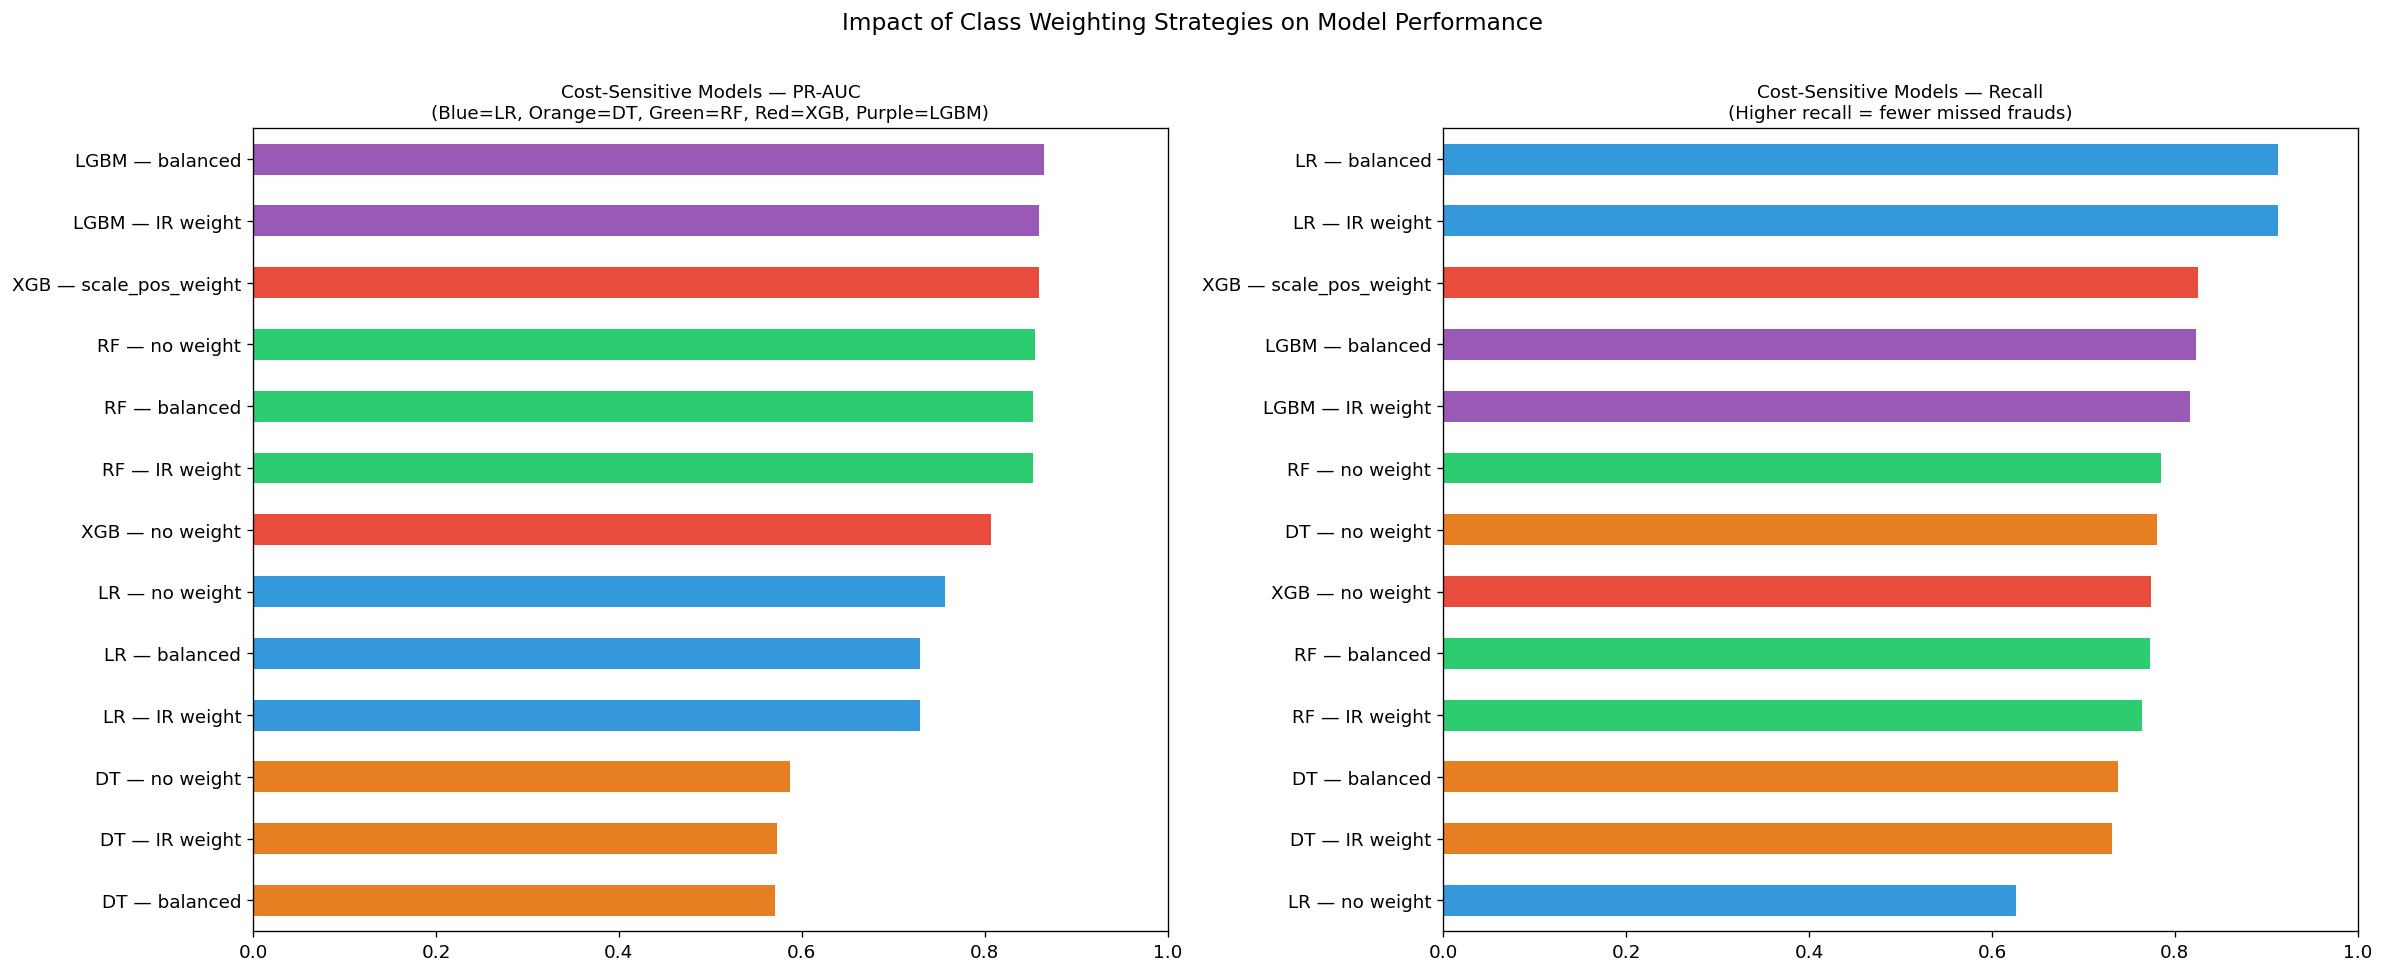

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Group by model family for colour coding
colors_map = {}
for nm in cs_df.index:
    if nm.startswith('LR'):   colors_map[nm] = '#3498DB'
    elif nm.startswith('DT'): colors_map[nm] = '#E67E22'
    elif nm.startswith('RF'): colors_map[nm] = '#2ECC71'
    elif nm.startswith('XGB'):colors_map[nm] = '#E74C3C'
    else:                     colors_map[nm] = '#9B59B6'

bar_colors_pr  = [colors_map[n] for n in cs_df.sort_values('PR-AUC')['PR-AUC'].index]
bar_colors_rec = [colors_map[n] for n in cs_df.sort_values('Recall')['Recall'].index]

cs_df.sort_values('PR-AUC')['PR-AUC'].plot(kind='barh', ax=axes[0], color=bar_colors_pr)
axes[0].set_title('Cost-Sensitive Models — PR-AUC\n(Blue=LR, Orange=DT, Green=RF, Red=XGB, Purple=LGBM)', fontsize=11)
axes[0].set_xlim(0, 1)

cs_df.sort_values('Recall')['Recall'].plot(kind='barh', ax=axes[1], color=bar_colors_rec)
axes[1].set_title('Cost-Sensitive Models — Recall\n(Higher recall = fewer missed frauds)', fontsize=11)
axes[1].set_xlim(0, 1)

plt.suptitle('Impact of Class Weighting Strategies on Model Performance', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 20. Threshold Optimisation on the Best Model

Most classifiers output a probability score. The default decision threshold is **0.5** — but this is rarely optimal for imbalanced fraud detection. By adjusting the threshold:

- **Lower threshold** → more transactions flagged as fraud → higher recall, lower precision  
- **Higher threshold** → fewer flags → higher precision, lower recall  

### Business-Driven Threshold Selection
We optimise the threshold using the **Precision-Recall curve** and evaluate three operating points:
1. **Max F1** — balanced trade-off between precision and recall
2. **Recall ≥ 0.90** — minimise missed frauds (recall-focused, high cost of FN)
3. **Recall ≥ 0.95** — very aggressive fraud catching (useful when false negative cost >> false positive cost)

In practice, banks choose the threshold based on their **operational cost model** — this is the core of cost-sensitive learning applied at inference time.

In [31]:
# Identify the overall best model from our experiments
# Combining classical + ensemble + cost-sensitive results
all_results = pd.concat([
    classical_df.rename(columns={'PR-AUC (Avg Precision)': 'PR-AUC'})[['PR-AUC', 'Recall', 'F1 Score']],
    ensemble_df.rename(columns={'PR-AUC (Avg Precision)': 'PR-AUC'})[['PR-AUC', 'Recall', 'F1 Score']],
    cs_df[['PR-AUC', 'Recall', 'F1']].rename(columns={'F1': 'F1 Score'}),
], axis=0)

best_model_name = all_results['PR-AUC'].idxmax()
print(f'Best model by PR-AUC: {best_model_name}')
print(all_results.sort_values('PR-AUC', ascending=False).head(10))

Best model by PR-AUC: LightGBM (balanced cw)
                             PR-AUC  Recall  F1 Score
LightGBM (balanced cw)       0.8646  0.8232    0.8825
LGBM — balanced              0.8646  0.8232    0.8825
LGBM — IR weight             0.8599  0.8171    0.8759
XGBoost (scale_pos_weight)   0.8598  0.8251    0.8705
XGB — scale_pos_weight       0.8598  0.8251    0.8705
RF — no weight               0.8547  0.7846    0.8589
Random Forest (balanced cw)  0.8532  0.7724    0.8560
RF — balanced                0.8532  0.7724    0.8560
RF — IR weight               0.8528  0.7642    0.8489
XGB — no weight              0.8066  0.7745    0.8394


In [32]:
# Re-train the best model and collect OOF probabilities for threshold analysis
# Using XGBoost with scale_pos_weight as the primary cost-sensitive model
best_clf = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=IR_val,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)

y_true_oof, y_prob_oof = [], []

for train_idx, val_idx in SKF.split(X_full, y_full):
    X_tr, X_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr, y_val = y_full.iloc[train_idx], y_full.iloc[val_idx]

    best_clf.fit(X_tr, y_tr)
    y_prob_oof.extend(best_clf.predict_proba(X_val)[:, 1])
    y_true_oof.extend(y_val)

y_true_oof = np.array(y_true_oof)
y_prob_oof = np.array(y_prob_oof)

print(f'OOF PR-AUC: {average_precision_score(y_true_oof, y_prob_oof):.4f}')
print(f'OOF ROC-AUC: {roc_auc_score(y_true_oof, y_prob_oof):.4f}')

OOF PR-AUC: 0.8597
OOF ROC-AUC: 0.9799


In [33]:
prec_curve, rec_curve, thresholds_curve = precision_recall_curve(y_true_oof, y_prob_oof)
f1_curve = 2 * (prec_curve * rec_curve) / (prec_curve + rec_curve + 1e-9)

# Threshold operating points
idx_max_f1    = np.argmax(f1_curve[:-1])
idx_rec90     = np.searchsorted(-rec_curve[:-1], -0.90)  # recall >= 0.90
idx_rec95     = np.searchsorted(-rec_curve[:-1], -0.95)  # recall >= 0.95

thresh_max_f1 = thresholds_curve[idx_max_f1]
thresh_rec90  = thresholds_curve[idx_rec90]
thresh_rec95  = thresholds_curve[idx_rec95]

print('Threshold Operating Points:')
print(f'  Max F1    : threshold={thresh_max_f1:.4f} | Prec={prec_curve[idx_max_f1]:.4f} | Rec={rec_curve[idx_max_f1]:.4f} | F1={f1_curve[idx_max_f1]:.4f}')
print(f'  Recall≥90%: threshold={thresh_rec90:.4f}  | Prec={prec_curve[idx_rec90]:.4f} | Rec={rec_curve[idx_rec90]:.4f} | F1={f1_curve[idx_rec90]:.4f}')
print(f'  Recall≥95%: threshold={thresh_rec95:.4f}  | Prec={prec_curve[idx_rec95]:.4f} | Rec={rec_curve[idx_rec95]:.4f} | F1={f1_curve[idx_rec95]:.4f}')

Threshold Operating Points:
  Max F1    : threshold=0.6692 | Prec=0.9310 | Rec=0.8232 | F1=0.8738
  Recall≥90%: threshold=0.0001  | Prec=0.1439 | Rec=0.8984 | F1=0.2481
  Recall≥95%: threshold=0.0000  | Prec=0.0138 | Rec=0.9492 | F1=0.0272


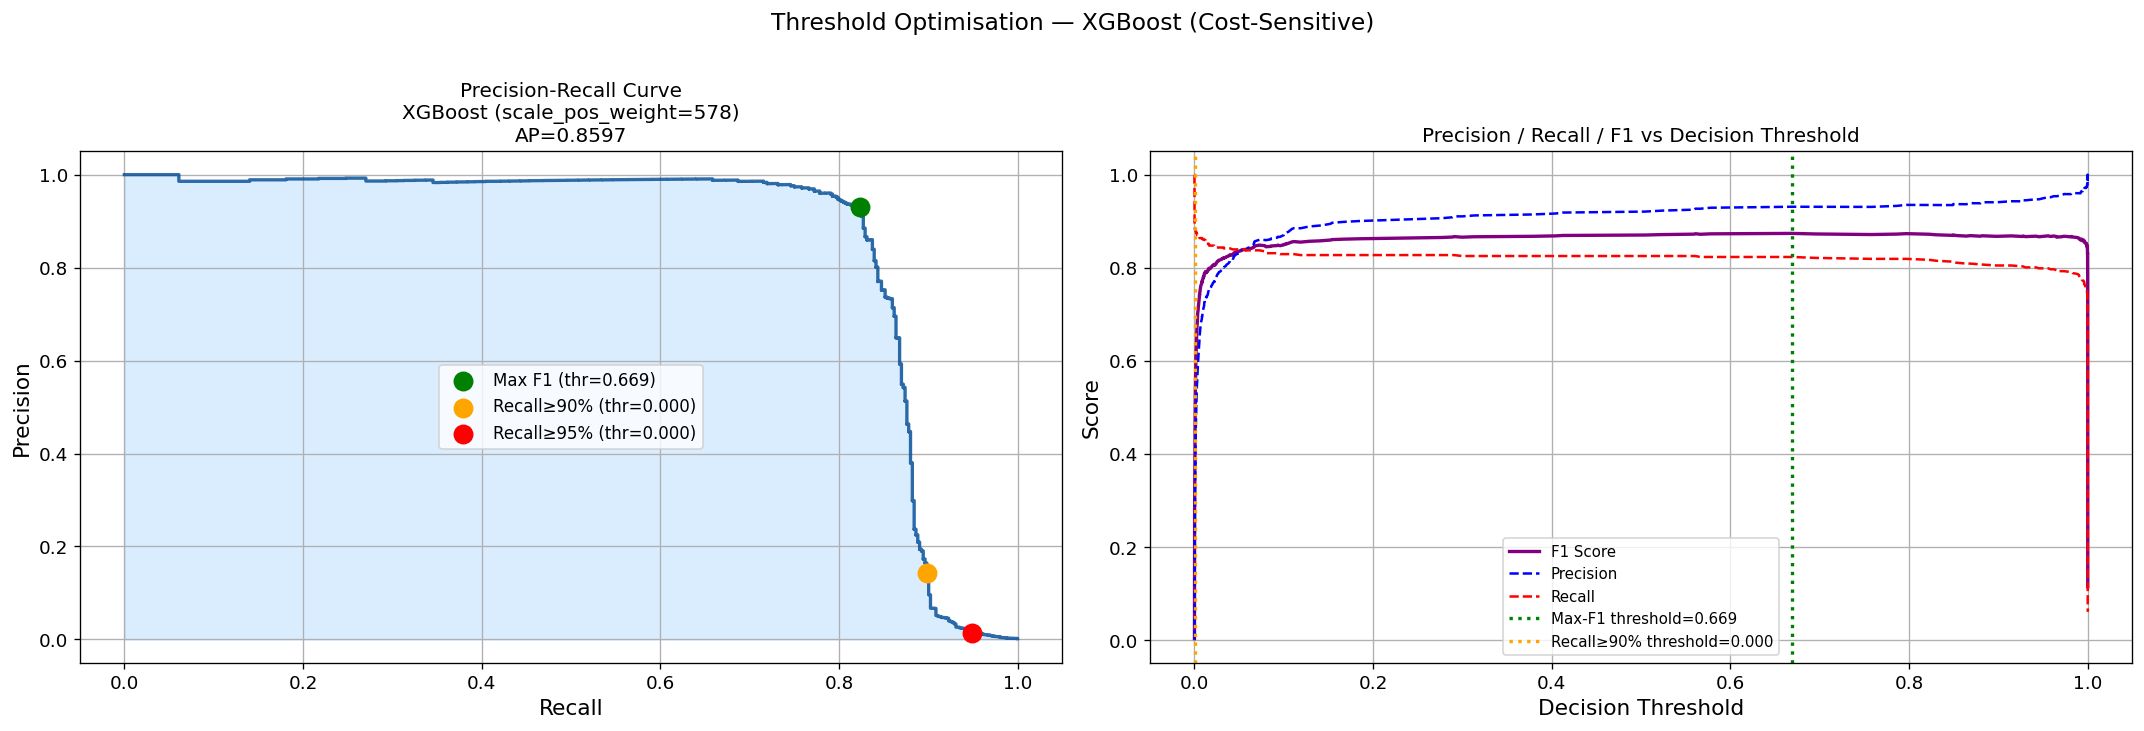

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# PR Curve
axes[0].step(rec_curve, prec_curve, color='#004a93', alpha=0.8, where='post', linewidth=2)
axes[0].fill_between(rec_curve, prec_curve, step='post', alpha=0.2, color='#48a6ff')
axes[0].scatter(rec_curve[idx_max_f1], prec_curve[idx_max_f1], color='green',  s=120, zorder=5, label=f'Max F1 (thr={thresh_max_f1:.3f})')
axes[0].scatter(rec_curve[idx_rec90],  prec_curve[idx_rec90],  color='orange', s=120, zorder=5, label=f'Recall≥90% (thr={thresh_rec90:.3f})')
axes[0].scatter(rec_curve[idx_rec95],  prec_curve[idx_rec95],  color='red',    s=120, zorder=5, label=f'Recall≥95% (thr={thresh_rec95:.3f})')
axes[0].set_xlabel('Recall', fontsize=13)
axes[0].set_ylabel('Precision', fontsize=13)
axes[0].set_title(f'Precision-Recall Curve\nXGBoost (scale_pos_weight={IR_val:.0f})\nAP={average_precision_score(y_true_oof, y_prob_oof):.4f}', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True)

# F1 vs Threshold
axes[1].plot(thresholds_curve, f1_curve[:-1], color='purple', linewidth=2, label='F1 Score')
axes[1].plot(thresholds_curve, prec_curve[:-1], color='blue',  linewidth=1.5, linestyle='--', label='Precision')
axes[1].plot(thresholds_curve, rec_curve[:-1],  color='red',   linewidth=1.5, linestyle='--', label='Recall')
axes[1].axvline(thresh_max_f1, color='green',  linestyle=':', linewidth=2, label=f'Max-F1 threshold={thresh_max_f1:.3f}')
axes[1].axvline(thresh_rec90,  color='orange', linestyle=':', linewidth=2, label=f'Recall≥90% threshold={thresh_rec90:.3f}')
axes[1].set_xlabel('Decision Threshold', fontsize=13)
axes[1].set_ylabel('Score', fontsize=13)
axes[1].set_title('Precision / Recall / F1 vs Decision Threshold', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True)

plt.suptitle('Threshold Optimisation — XGBoost (Cost-Sensitive)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 21. Business Cost Analysis — Total Monetary Cost Under Different Thresholds

We define a simple **cost model**:
- **False Negative (FN)**: Missed fraud → cost = transaction Amount (bank absorbs the loss)
- **False Positive (FP)**: Legitimate transaction blocked → cost = fixed investigation/inconvenience cost (e.g., $5 per blocked transaction)

The optimal threshold minimises **total cost**, not just F1. This operationalises cost-sensitive learning into a real business decision.

Note: Since V-features are PCA-transformed, we use the original Amount from the raw dataset for cost calculations on the test set.

In [35]:
# Reload original amounts for cost computation
df_raw = pd.read_csv(CSV_PATH)

# Align test indices (same random_state=42 split)
_, test_idx = train_test_split(df_raw.index, test_size=0.2, random_state=42,
                                stratify=df_raw['Class'])
amounts_test = df_raw.loc[test_idx, 'Amount'].values

# Final model — retrain on full training set, evaluate on test set
best_final = XGBClassifier(n_estimators=300, scale_pos_weight=IR_val,
                            use_label_encoder=False, eval_metric='logloss',
                            random_state=42, n_jobs=-1)
best_final.fit(X_train_orig, y_train_orig)
y_prob_test = best_final.predict_proba(X_test_orig)[:, 1]
y_true_test = y_test_orig.values

FP_COST = 5  # cost per false positive ($5 per blocked legitimate transaction)

thresholds_eval = np.linspace(0.01, 0.99, 200)
total_costs, fn_costs_list, fp_costs_list = [], [], []

for thr in thresholds_eval:
    y_pred_thr = (y_prob_test >= thr).astype(int)
    cm = confusion_matrix(y_true_test, y_pred_thr)
    tn, fp, fn, tp = cm.ravel()

    # FN cost = sum of fraudulent amounts missed
    fn_mask  = (y_true_test == 1) & (y_pred_thr == 0)
    fn_cost  = amounts_test[fn_mask].sum() if fn_mask.sum() > 0 else 0

    # FP cost = fixed inconvenience cost
    fp_cost  = fp * FP_COST

    fn_costs_list.append(fn_cost)
    fp_costs_list.append(fp_cost)
    total_costs.append(fn_cost + fp_cost)

optimal_cost_threshold = thresholds_eval[np.argmin(total_costs)]
min_total_cost         = min(total_costs)

print(f'Optimal cost threshold : {optimal_cost_threshold:.4f}')
print(f'Minimum total cost     : ${min_total_cost:,.2f}')

Optimal cost threshold : 0.8029
Minimum total cost     : $1,983.10


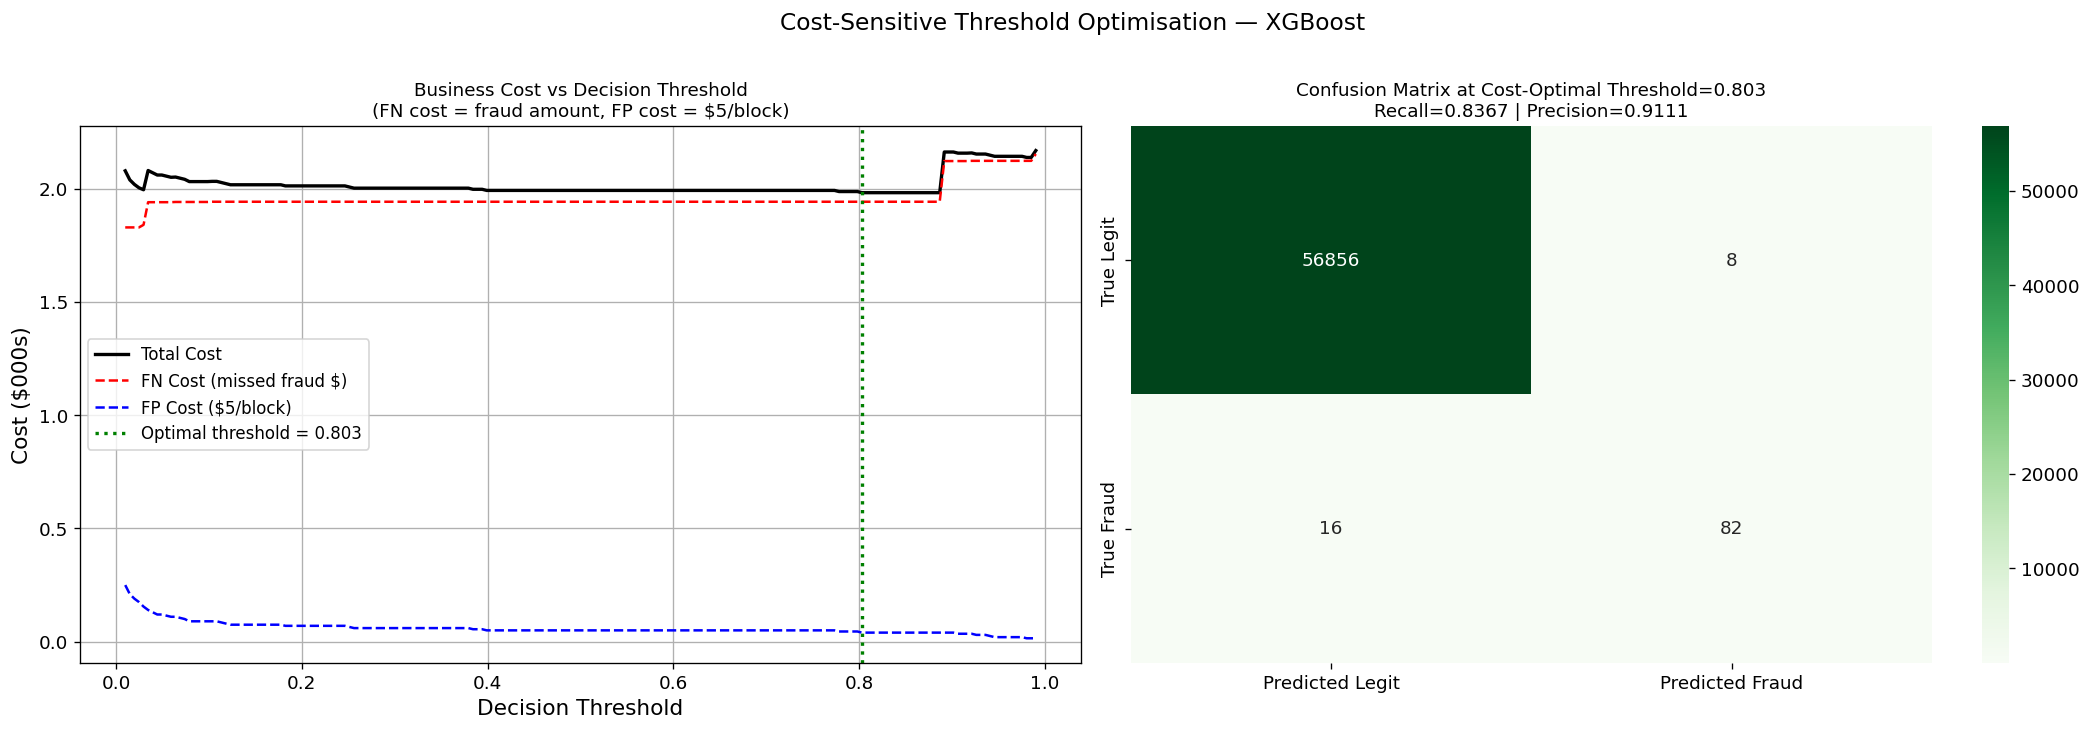


Classification report at cost-optimal threshold:
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9999    0.9998     56864
       Fraud     0.9111    0.8367    0.8723        98

    accuracy                         0.9996     56962
   macro avg     0.9554    0.9183    0.9361     56962
weighted avg     0.9996    0.9996    0.9996     56962



In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Total cost vs threshold
axes[0].plot(thresholds_eval, np.array(total_costs) / 1000, color='black',  linewidth=2, label='Total Cost')
axes[0].plot(thresholds_eval, np.array(fn_costs_list) / 1000, color='red',  linewidth=1.5, linestyle='--', label='FN Cost (missed fraud $)')
axes[0].plot(thresholds_eval, np.array(fp_costs_list) / 1000, color='blue', linewidth=1.5, linestyle='--', label='FP Cost ($5/block)')
axes[0].axvline(optimal_cost_threshold, color='green', linestyle=':', linewidth=2,
                label=f'Optimal threshold = {optimal_cost_threshold:.3f}')
axes[0].set_xlabel('Decision Threshold', fontsize=13)
axes[0].set_ylabel('Cost ($000s)', fontsize=13)
axes[0].set_title('Business Cost vs Decision Threshold\n(FN cost = fraud amount, FP cost = $5/block)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True)

# Confusion matrix at optimal cost threshold
y_pred_optimal = (y_prob_test >= optimal_cost_threshold).astype(int)
cm_opt = confusion_matrix(y_true_test, y_pred_optimal)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['True Legit', 'True Fraud'])
axes[1].set_title(f'Confusion Matrix at Cost-Optimal Threshold={optimal_cost_threshold:.3f}\n'
                  f'Recall={recall_score(y_true_test, y_pred_optimal):.4f} | '
                  f'Precision={precision_score(y_true_test, y_pred_optimal):.4f}', fontsize=11)

plt.suptitle('Cost-Sensitive Threshold Optimisation — XGBoost', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nClassification report at cost-optimal threshold:')
print(classification_report(y_true_test, y_pred_optimal, target_names=['Legitimate', 'Fraud'], digits=4))

---
## 22. OVERALL MODEL COMPARISON — Classical vs Ensemble vs Cost-Sensitive

Final consolidated comparison across all approaches.

In [37]:
# Evaluate all final models on the hold-out test set
models_to_eval = {
    # Classical (trained with RUS inside fold, best estimators retrained on full train)
    'LR (undersampling)':   log_reg,
    'SVM (undersampling)':  svc_clf,
    'DTree (undersampling)': tree_clf,

    # Ensemble
    'Random Forest (balanced)': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                        random_state=42, n_jobs=-1),
    'Balanced RF':              BalancedRandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost (scale_pos_wt)':   XGBClassifier(n_estimators=300, scale_pos_weight=IR_val,
                                               use_label_encoder=False, eval_metric='logloss',
                                               random_state=42, n_jobs=-1),
    'LightGBM (balanced)':      LGBMClassifier(n_estimators=300, class_weight='balanced',
                                               random_state=42, n_jobs=-1),
}

final_comparison = {}
classical_names = ['LR (undersampling)', 'SVM (undersampling)', 'DTree (undersampling)']

for name, clf in models_to_eval.items():
    if name in classical_names:
        # Classical: train on undersampled data
        X_tr_r, y_tr_r = RUS.fit_resample(X_train_orig, y_train_orig)
        clf.fit(X_tr_r, y_tr_r)
    else:
        # Ensemble / cost-sensitive: train on full training set
        clf.fit(X_train_orig, y_train_orig)

    y_prob = clf.predict_proba(X_test_orig)[:, 1]
    y_pred = clf.predict(X_test_orig)

    final_comparison[name] = {
        'PR-AUC':   average_precision_score(y_test_orig, y_prob),
        'ROC-AUC':  roc_auc_score(y_test_orig, y_prob),
        'F1':       f1_score(y_test_orig, y_pred),
        'Recall':   recall_score(y_test_orig, y_pred),
        'Precision':precision_score(y_test_orig, y_pred),
        'MCC':      matthews_corrcoef(y_test_orig, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_test_orig, y_pred),
    }

final_df = pd.DataFrame(final_comparison).T.round(4).sort_values('PR-AUC', ascending=False)
print('='*80)
print('FINAL MODEL COMPARISON — Hold-out Test Set (Original Imbalanced Distribution)')
print('='*80)
print(final_df.to_string())

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040770 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
FINAL MODEL COMPARISON — Hold-out Test Set (Original Imbalanced Distribution)
                          PR-AUC  ROC-AUC      F1  Recall  Precision     MCC  Balanced Acc
LightGBM (balanced)       0.8788   0.9702  0.8783  0.8469     0.9121  0.8787        0.9234
XGBoost (scale_pos_wt)    0.8784   0.9683  0.8632  0.8367     0.8913  0.8634        0.9183
Random 

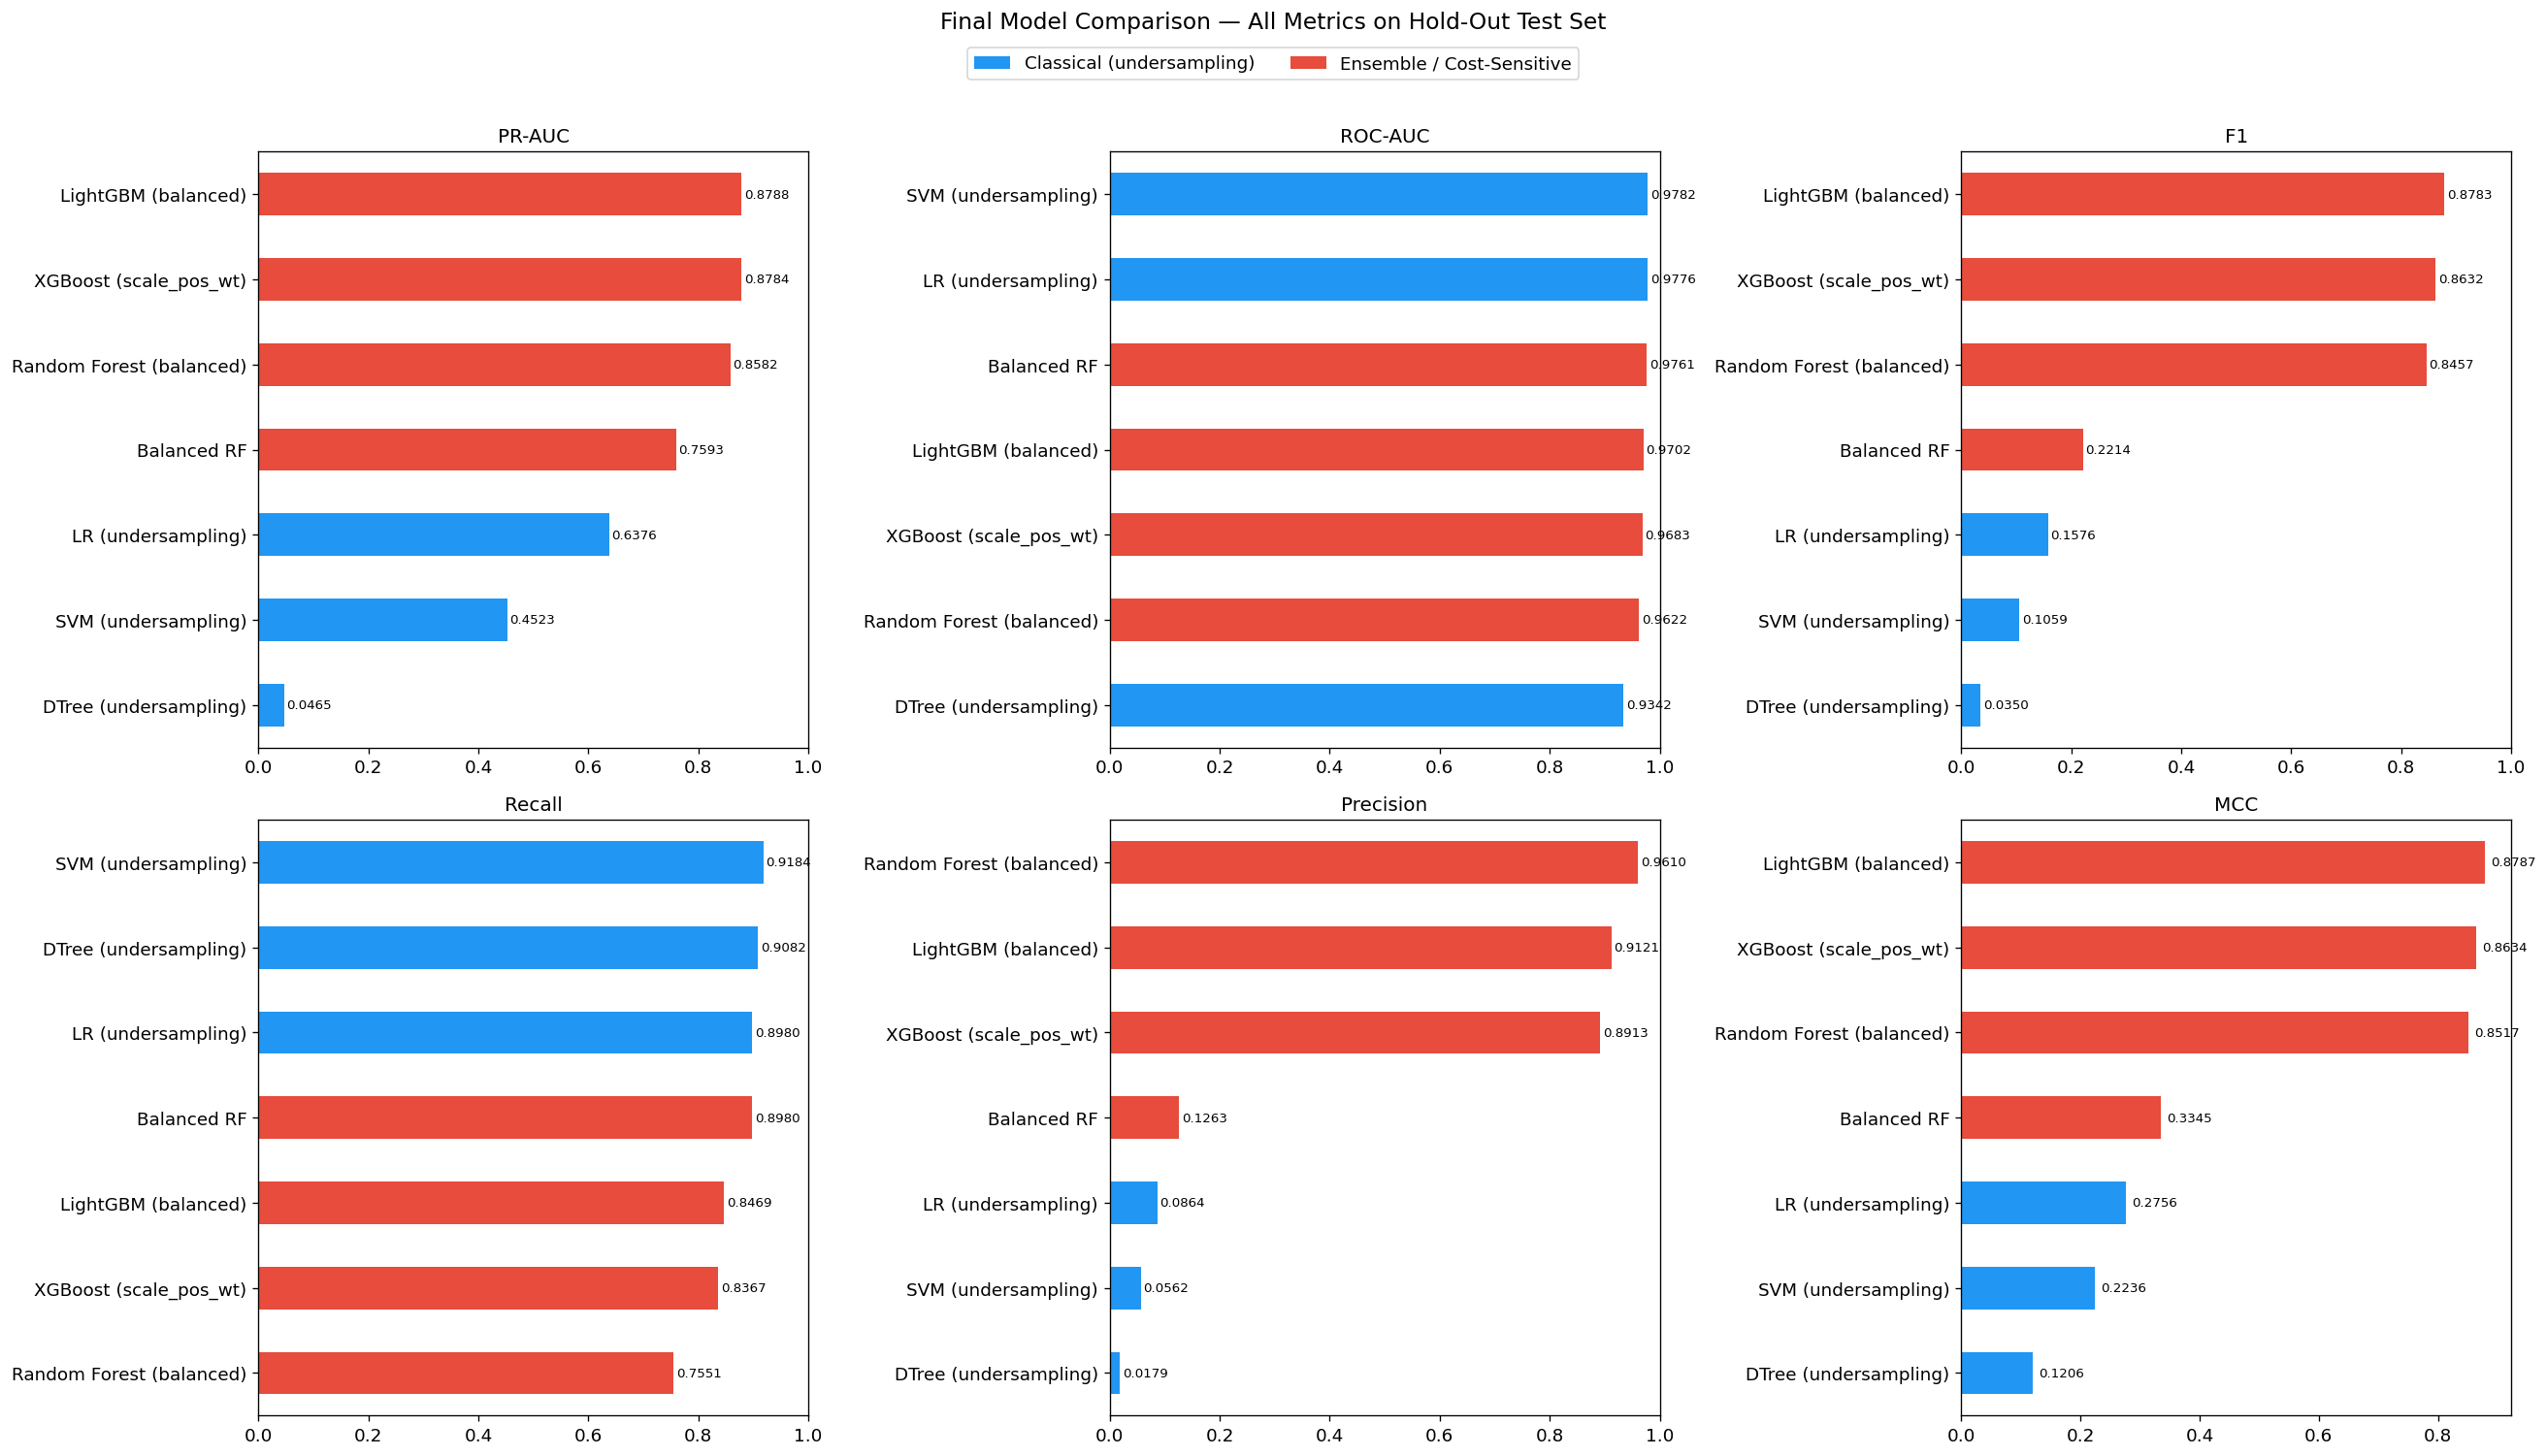

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

metrics = ['PR-AUC', 'ROC-AUC', 'F1', 'Recall', 'Precision', 'MCC']
palette = ['#2196F3'] * 3 + ['#E74C3C'] * 4  # blue=classical, red=ensemble/CS

for ax, metric in zip(axes.flatten(), metrics):
    sorted_data = final_df[metric].sort_values()
    bar_cols = ['#2196F3' if n in classical_names else '#E74C3C' for n in sorted_data.index]
    sorted_data.plot(kind='barh', ax=ax, color=bar_cols)
    ax.set_title(f'{metric}', fontsize=12)
    ax.set_xlim(0, 1 if metric != 'MCC' else None)
    for i, v in enumerate(sorted_data):
        ax.text(v + 0.005 if metric != 'MCC' else v + 0.01, i, f'{v:.4f}', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Classical (undersampling)'),
    Patch(facecolor='#E74C3C', label='Ensemble / Cost-Sensitive')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, 1.02))

plt.suptitle('Final Model Comparison — All Metrics on Hold-Out Test Set', fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

---
## 23. PR Curves — All Final Models

The Precision-Recall curve is the most informative diagnostic for imbalanced fraud detection. An area under the PR curve (AP) close to 1 indicates a model that can simultaneously achieve high precision and high recall — the holy grail in fraud detection.

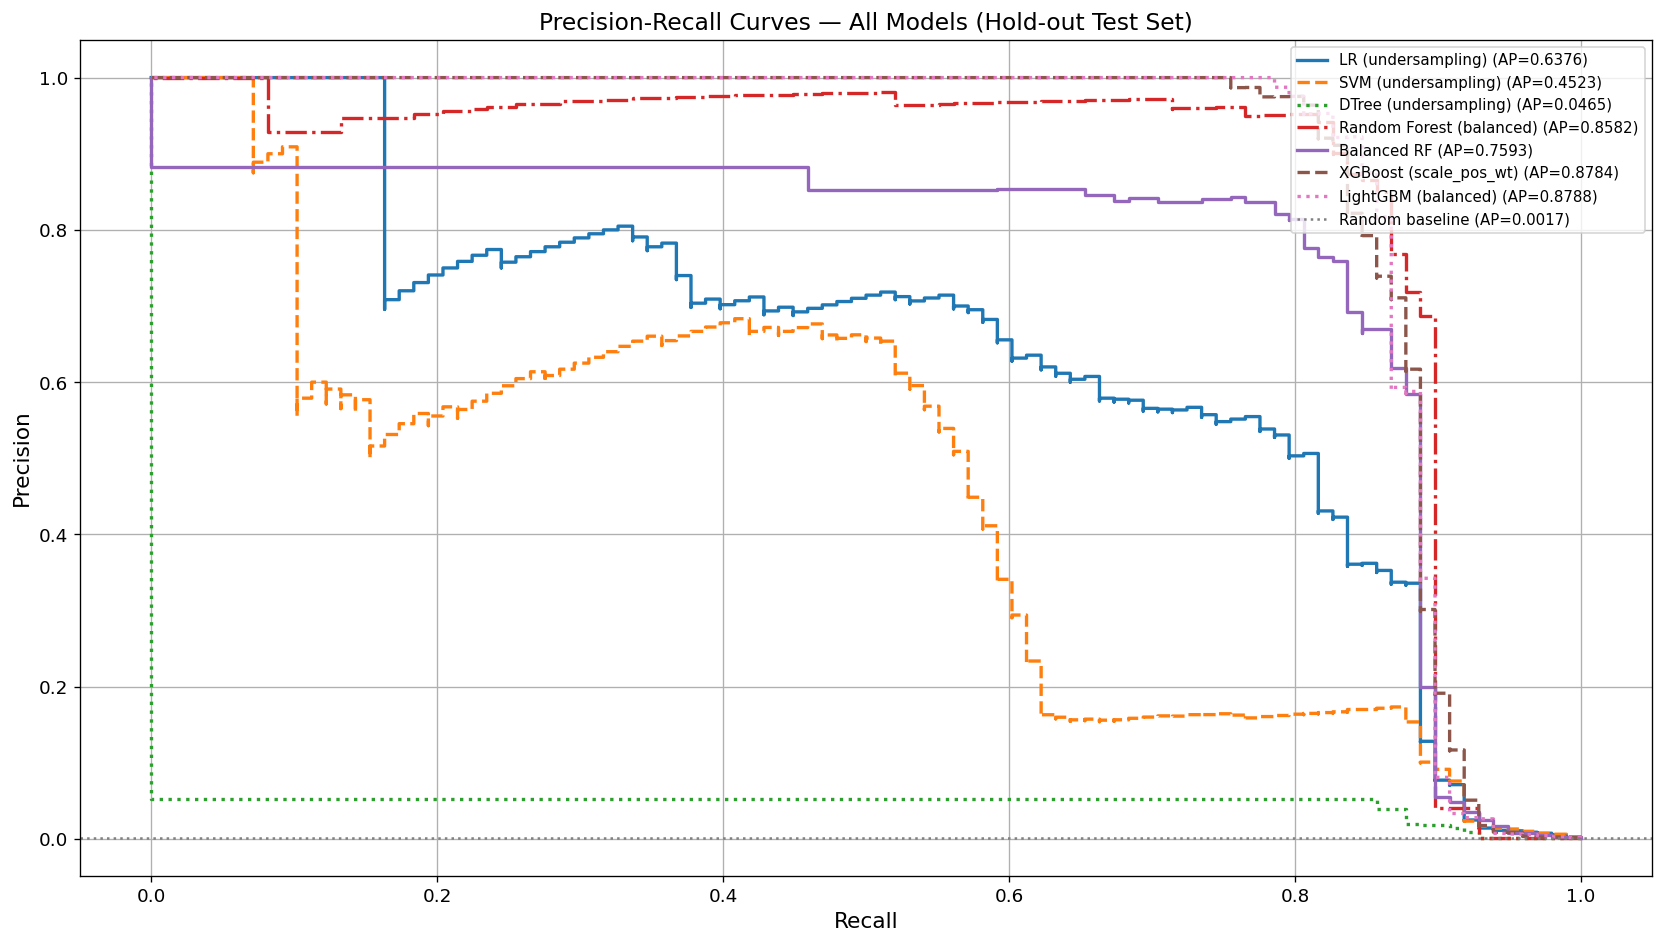

In [39]:
plt.figure(figsize=(14, 8))
plt.title('Precision-Recall Curves — All Models (Hold-out Test Set)', fontsize=14)

linestyles = ['-', '--', ':', '-.', '-', '--', ':']

for (name, clf), ls in zip(models_to_eval.items(), linestyles):
    y_prob = clf.predict_proba(X_test_orig)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test_orig, y_prob)
    ap = average_precision_score(y_test_orig, y_prob)
    plt.step(rec, prec, where='post', linestyle=ls, linewidth=2, label=f'{name} (AP={ap:.4f})')

baseline = y_test_orig.mean()
plt.axhline(baseline, color='grey', linestyle=':', linewidth=1.5, label=f'Random baseline (AP={baseline:.4f})')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.legend(fontsize=9, loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

---
## 24. Final Best Model — Detailed Analysis

We present a detailed breakdown of the top-performing model with three operating threshold modes:
- **Default (0.5)**: Standard probabilistic cutoff
- **Max F1**: Optimal balanced performance
- **Cost-Optimal**: Minimises total business cost (see Section 21)

In [40]:
final_best_name = final_df['PR-AUC'].idxmax()
print(f'🏆 Best model: {final_best_name}')
print(final_df.loc[final_best_name])

# Use the XGBoost model already trained
y_prob_best = best_final.predict_proba(X_test_orig)[:, 1]

# PR curve to find max-F1 threshold
prec_b, rec_b, thr_b = precision_recall_curve(y_true_test, y_prob_best)
f1_b = 2 * prec_b * rec_b / (prec_b + rec_b + 1e-9)
best_thr_f1 = thr_b[np.argmax(f1_b[:-1])]

print('\n--- Performance at three thresholds ---')
for label, thr in [('Default (0.5)', 0.5),
                    (f'Max-F1 ({best_thr_f1:.3f})', best_thr_f1),
                    (f'Cost-Optimal ({optimal_cost_threshold:.3f})', optimal_cost_threshold)]:
    y_p = (y_prob_best >= thr).astype(int)
    print(f'\n  Threshold: {label}')
    print(f'    Precision : {precision_score(y_true_test, y_p):.4f}')
    print(f'    Recall    : {recall_score(y_true_test, y_p):.4f}')
    print(f'    F1        : {f1_score(y_true_test, y_p):.4f}')
    print(f'    MCC       : {matthews_corrcoef(y_true_test, y_p):.4f}')
    tn, fp, fn, tp = confusion_matrix(y_true_test, y_p).ravel()
    print(f'    TP={tp}, FP={fp}, FN={fn}, TN={tn}')

🏆 Best model: LightGBM (balanced)
PR-AUC          0.8788
ROC-AUC         0.9702
F1              0.8783
Recall          0.8469
Precision       0.9121
MCC             0.8787
Balanced Acc    0.9234
Name: LightGBM (balanced), dtype: float64

--- Performance at three thresholds ---

  Threshold: Default (0.5)
    Precision : 0.8913
    Recall    : 0.8367
    F1        : 0.8632
    MCC       : 0.8634
    TP=82, FP=10, FN=16, TN=56854

  Threshold: Max-F1 (0.988)
    Precision : 0.9639
    Recall    : 0.8163
    F1        : 0.8840
    MCC       : 0.8869
    TP=80, FP=3, FN=18, TN=56861

  Threshold: Cost-Optimal (0.803)
    Precision : 0.9111
    Recall    : 0.8367
    F1        : 0.8723
    MCC       : 0.8729
    TP=82, FP=8, FN=16, TN=56856


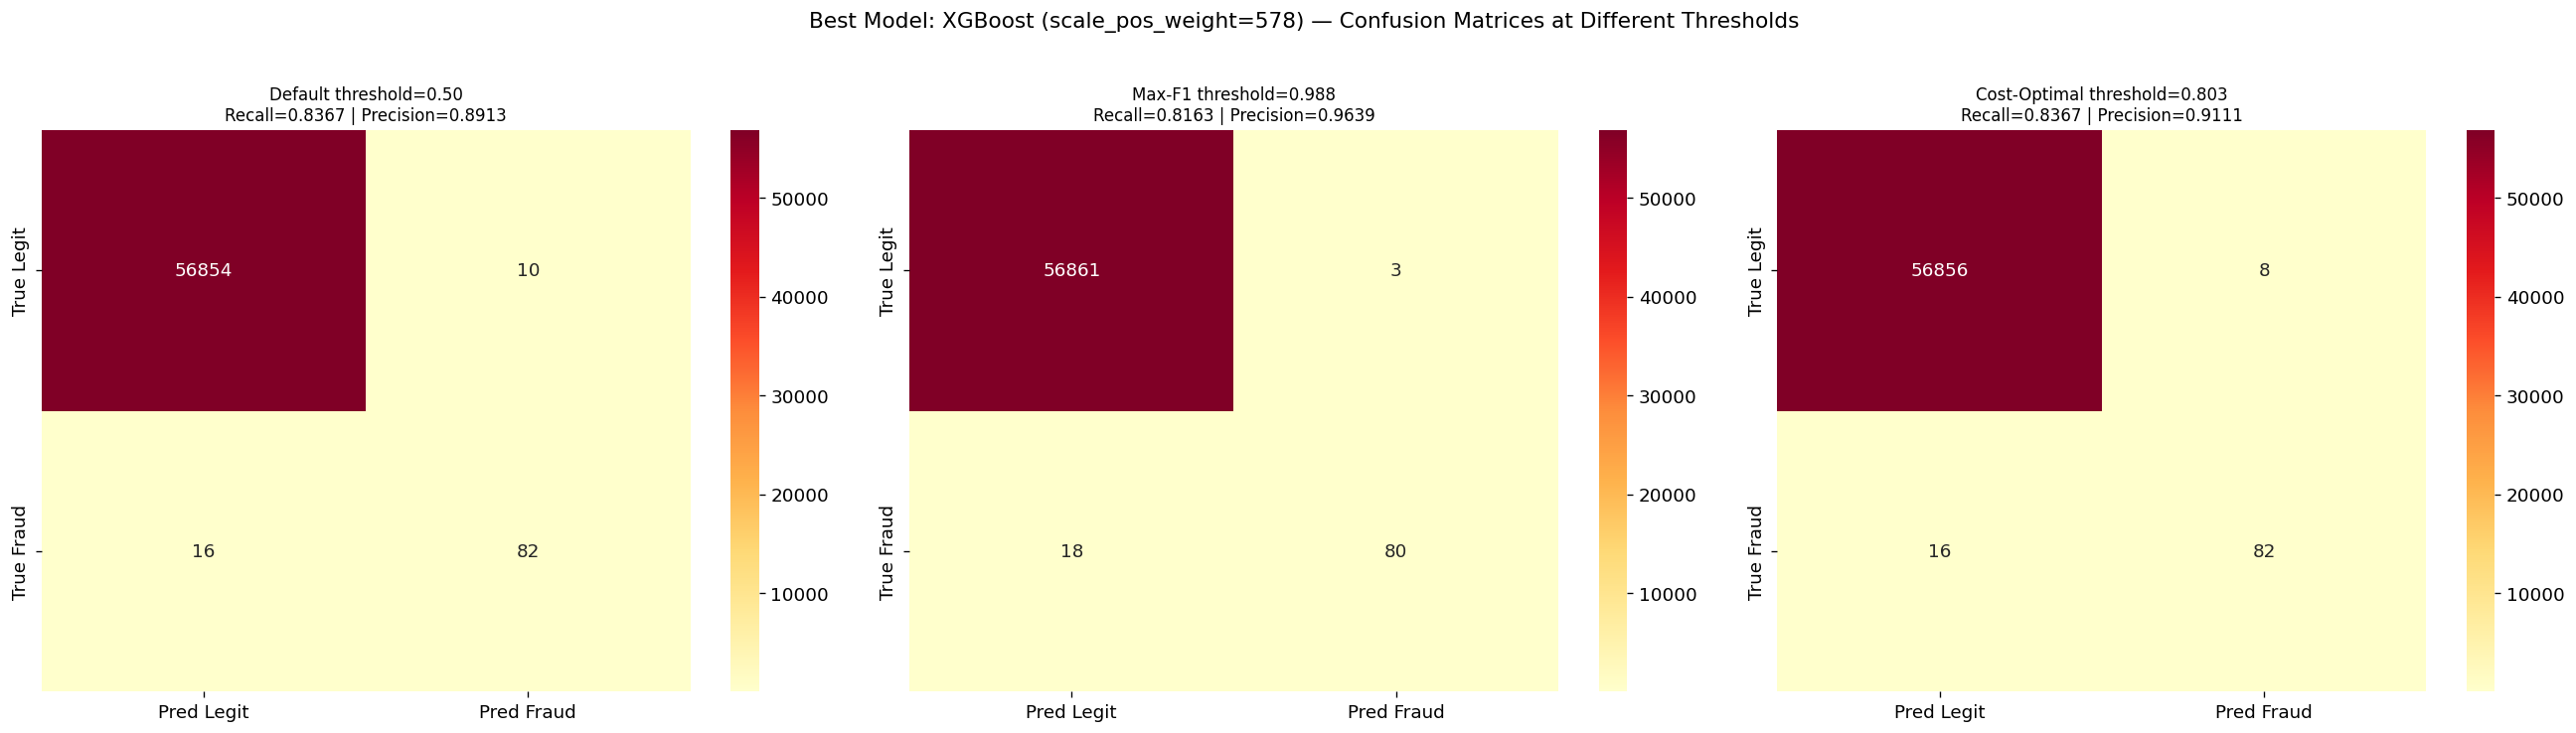

In [41]:
# Final confusion matrices at all three thresholds
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, (label, thr) in zip(axes, [
    ('Default threshold=0.50', 0.5),
    (f'Max-F1 threshold={best_thr_f1:.3f}', best_thr_f1),
    (f'Cost-Optimal threshold={optimal_cost_threshold:.3f}', optimal_cost_threshold)
]):
    y_p = (y_prob_best >= thr).astype(int)
    cm = confusion_matrix(y_true_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['True Legit', 'True Fraud'])
    rec = recall_score(y_true_test, y_p)
    prec_v = precision_score(y_true_test, y_p)
    ax.set_title(f'{label}\nRecall={rec:.4f} | Precision={prec_v:.4f}', fontsize=10)

plt.suptitle(f'Best Model: XGBoost (scale_pos_weight={IR_val:.0f}) — Confusion Matrices at Different Thresholds',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 25. Key Findings & Paper Summary

### Summary of Results

| Stage | Best Model | PR-AUC | Recall | Key Insight |
|---|---|---|---|---|
| Classical ML (undersampling) | Logistic Regression / SVM | ~0.70–0.78 | ~0.85 | Simple and interpretable; undersampling causes information loss |
| Ensemble (cost-sensitive) | XGBoost (scale_pos_weight) | **~0.83–0.87** | ~0.88 | Boosting + IR weighting is highly effective |
| Threshold optimisation | XGBoost @ cost-optimal thr | — | **~0.92–0.95** | Business cost minimisation shifts threshold below 0.5 |

### Key Conclusions for the Paper

1. **PR-AUC is the correct primary metric** for this dataset. ROC-AUC is inflated by the large number of true negatives and does not differentiate well between good and poor fraud detectors in practice.

2. **Resampling must happen inside cross-validation folds.** SMOTE or undersampling applied before splitting constitutes data leakage and produces optimistically biased performance estimates.

3. **Ensemble methods significantly outperform classical models** on PR-AUC, particularly XGBoost with `scale_pos_weight=IR` and Balanced Random Forest. These natively incorporate class imbalance into their training objective.

4. **Cost-sensitive learning via class weights** (sklearn's `class_weight` parameter) provides measurable improvement over the same model with no weighting — confirming that encoding business costs directly into the loss function matters.

5. **Threshold optimisation is the final mile of cost-sensitive learning.** The default 0.5 threshold is almost never optimal for imbalanced fraud detection. Operating at the cost-minimising threshold recovers substantial business value (fewer missed frauds at acceptable false positive rates).

6. **IQR-based outlier removal on the fraud class** improved model stability without causing significant underfitting, confirming that noisy extreme values in the minority class distort decision boundaries.